In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pre_processing import pre_process, json_decode


sns.set_palette("hsv_r")

# This affects things like the size of the labels, lines, and other elements of the plot, but not the overall style. 
# The base context is “notebook”, and the other contexts are “paper”, “talk”, and “poster”, which are version of 
# the notebook parameters scaled by .8, 1.3, and 1.6, respectively.
sns.set_context("talk")

%config Inline.figure_format = 'retina'
%matplotlib inline

## Read in Data 

In [45]:
# File paths for each experimental condition (can contain multiple subjects/files) 
file_paths_baseline = [
    "../data/csv_files/01_baseline_withFB.csv",
    "../data/csv_files/02_baseline_withFB.csv",
    "../data/csv_files/03_baseline_withFB.csv",
    "../data/csv_files/04_baseline_withFB.csv", 
    "../data/csv_files/05_baseline_withFB.csv", 
    "../data/csv_files/jeremy_pilot_baseline.csv"
]

file_paths_repulse = [
    "../data/csv_files/01_repulse_withFB.csv",
    "../data/csv_files/02_repulse_withFB.csv",
    "../data/csv_files/03_repulse_withFB.csv",
    "../data/csv_files/04_repulse_withFB.csv", 
    "../data/csv_files/05_repulse_withFB.csv", 
    "../data/csv_files/jeremy_pilot_repulse.csv"
]

file_paths_udl = [
    "../data/csv_files/01_udl_withFB.csv",
    "../data/csv_files/02_udl_withFB.csv",
    "../data/csv_files/03_udl_withFB.csv",
    "../data/csv_files/04_udl_withFB.csv", 
    "../data/csv_files/05_udl_withFB.csv", 
    "../data/csv_files/jeremy_pilot_udl_withFB.csv"
]

# Subject identifiers corresponding to the datasets
# We will change this with the randomly generated subject ID 
subject_list = ["eric", "abby", "rainie", "alice", "rhys", "jeremy"]


# Load CSV files & label condition
df_baseline_raw = pre_process(file_paths_baseline, subject_list)
df_baseline_raw['phase'] = 'baseline'

df_repulse_raw = pre_process(file_paths_repulse, subject_list)
df_repulse_raw['phase'] = 'repulse'

df_udl_raw = pre_process(file_paths_udl, subject_list)
df_udl_raw['phase'] = 'udl'

# Combine all conditions into a single dataset
df = pd.concat([df_baseline_raw, df_repulse_raw, df_udl_raw]).reset_index(drop=True)

# Reset the trial number column that resets for each subject
df["TN"] = df.groupby("SN").cumcount()

# CHECK 
# print(df['phase'].value_counts())
# print(df.head())

## Define Functions 

In [46]:
# function to unpack repeated target value from series
# WE HAVENT USE THIS ONE YET.. copied from Jeremy's analysis script
def find_rep(group):
    vals = group['Repeated_Target'].iloc[0]
    return vals[1:4]   

#function returns df where N-1 is a single target, 
#to compare the repulsive and attractive effect of a single target
def N_finder(group, N_minus_targ):
    N_trial_num = group.loc[(group['target_angle'] == N_minus_targ),'TN'] + 1
    N_df = group.loc[(group['TN'].isin(N_trial_num))]
    return N_df

def add_bias_correction(df, angle_col, phase_name, epoch):
    """
    calculate target-specific bias and corrected angle for a given phase and angle column
    """
    bias_col = f"bias_{phase_name}_{angle_col}"
    corrected_col = f"corrected_{phase_name}_{angle_col}"

    bias = (
        df.loc[
            (df["TN"] >= epoch[0]) &
            (df["TN"] <= epoch[1]) &
            (~df["mt"].isna()) &
            (df["rt"] > 0.5) &
            (df[angle_col].abs() < 60)
        ]
        .groupby(["SN", "target_angle"], as_index=False)[angle_col]
        .mean()
        .rename(columns={angle_col: bias_col})
    )

    # merge bias back into dataframe
    df = df.merge(bias, on=["SN", "target_angle"], how="left")

    # wrap the angle
    diff = np.deg2rad(df[angle_col] - df[bias_col])

    df[corrected_col] = np.rad2deg(
        np.arctan2(np.sin(diff), np.cos(diff))
    )
    return df

def calculate_se_index(df, y_col):
    """
    calculate the sequential effect (SE) index per participant 
    POSITIVE SE Index = attractive bias (UDL)
    NEGATIVE SE Index = repulsive bias (REPULSE)

    parameters: 
    df : DataFrame; data to calculate SE index from
    y_col : str; column containing corrected bias

    output: 
    df with the SE index per participant 
    """
    negative_mean = df.loc[df["target_angle_diff"] < 0].groupby("SN")[y_col].mean()
    positive_mean = df.loc[df["target_angle_diff"] > 0].groupby("SN")[y_col].mean()

    return negative_mean - positive_mean 


## should probably create a function that determines the repeated target and changes all the targets to be centred around ZERO 

## Data Wrangling 

In [47]:
## Define epochs for each phase of the experiment (trial number ranges for each phase)
epochs = {
    'baseline':(0, 15),                 # Baseline reaching
    'repulse':(16, 715),                # Main experiment block
    'repulse_clean':(116, 715),         # For repulse bias correctinon
    'udl_baseline_FB': (716, 785),      # Baseline reaching 
    'udl_baseline_noFB': (786, 855),    # For UDL bias corrrection  
    'udl_baseline_noFB_second_half': (821, 855),    # For UDL bias corrrection  
    'udl':(856, 1719),                  # Main experiment block
    'udl_full':(716, 1719),                  # including the baseline
}
## change the EPOCHS so its not inclusive?? --> makes it more intuitive?? 

## running add_bias_correction for all angle calculations & 
angle_cols = ["theta_40", "theta_100", "theta_pv", "theta_end"]
phase_info = {
    "repulse": epochs["repulse_clean"],
    "udl": epochs["udl_baseline_noFB"]
}

for phase_name, epoch in phase_info.items():
    for angle in angle_cols:
        df = add_bias_correction(
            df,
            angle_col=angle,
            phase_name=phase_name,
            epoch=epoch
        )

## Shift the target angles for participants who had a central target of 60 degrees, so that central target is always at 150 degrees 
# Participants who had central target as 60 degrees
# May want to update this so it doesnt have to be hard coded in 
p_list1 = [1, 3, 5, 6]

# Shift all targets so central target is always 150 degrees
mask = df['SN'].isin(set(p_list1))
TA_rad_shift = np.deg2rad(df.loc[mask]['target_angle']) + np.deg2rad(90)
df.loc[mask,'target_angle'] = (np.rad2deg(np.arctan2(np.sin(TA_rad_shift), np.cos(TA_rad_shift))) % 360).round()


# Get target location difference (delta target angle) values
df['target_angle_diff'] = pd.Series(pd.NA, index=df.index, dtype='Float64')
# NOTES:
# 1) CW is negative, CCW is positive 
# 2) add one to starting index because we want the first trial for every block to be NA
mask = (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1])
RadTAN1diff_repulse = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1))
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_repulse), np.cos(RadTAN1diff_repulse)))

mask = (df['TN'] >= epochs['udl_full'][0]) & (df['TN'] <= epochs['udl_full'][1])
RadTAN1diff_udl = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1))
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_udl), np.cos(RadTAN1diff_udl)))

# Round 
df['target_angle_diff'] = df['target_angle_diff'].round().astype('Int64')

In [48]:
# ## THIS CAN PROBABLY BE COMMENTED?

# # Calculate bias for each participant (for REPULSE), which is used for bias correction in the UDL condition
# bias_subset = (
#     df.loc[(df['TN'] >= epochs['repulse_clean'][0]) & (df['TN'] <= epochs['repulse_clean'][1]) & 
#     # df.loc[(df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
#     (~df['mt'].isna()) & (df['rt'] > .500) & (df['theta_pv'].abs() < 60)]
#     .groupby(['SN', 'target_angle'], as_index=False)['theta_pv']
#     .mean()
#     .rename(columns={'theta_pv': 'bias_repulse'})
# )

# df = df.merge(bias_subset, on=['SN', 'target_angle'], how='left')

# # Correct for target-level reach biases (for REPULSE) by subtraction of mean hand angle to a target
# RadCorrDiff = np.deg2rad(df['theta_pv'] - df['bias_repulse'])
# df['angle_error_corrected_repulse'] = np.rad2deg(np.arctan2(np.sin(RadCorrDiff), np.cos(RadCorrDiff)))

# # Calculate bias for each participant (for UDL), which is used for bias correction in the UDL condition
# bias_subset = (
#     df.loc[(df['TN'] >= epochs['udl_baseline_noFB'][0]) & (df['TN'] <= epochs['udl_baseline_noFB'][1]) & 
#     (~df['mt'].isna()) & (df['rt'] > .500) & (df['theta_pv'].abs() < 60)]
#     .groupby(['SN', 'target_angle'], as_index=False)['theta_pv']
#     .mean()
#     .rename(columns={'theta_pv': 'bias_udl'})
# )

# df = df.merge(bias_subset, on=['SN', 'target_angle'], how='left')

# # Correct for target-level reach biases (for UDL) by subtraction of mean hand angle to a target
# RadCorrDiff = np.deg2rad(df['theta_pv'] - df['bias_udl'])
# df['angle_error_corrected_udl'] = np.rad2deg(np.arctan2(np.sin(RadCorrDiff), np.cos(RadCorrDiff)))

# Plot bias across all random phase trials (using theta_pv)

Text(0, 0.5, 'Corrected Bias')

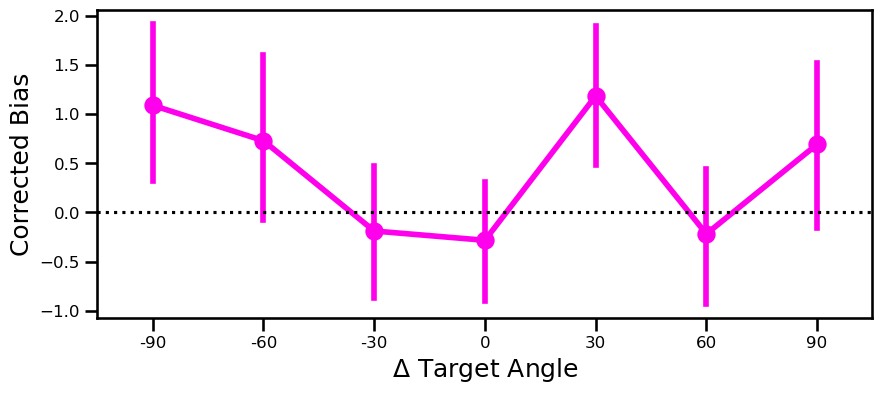

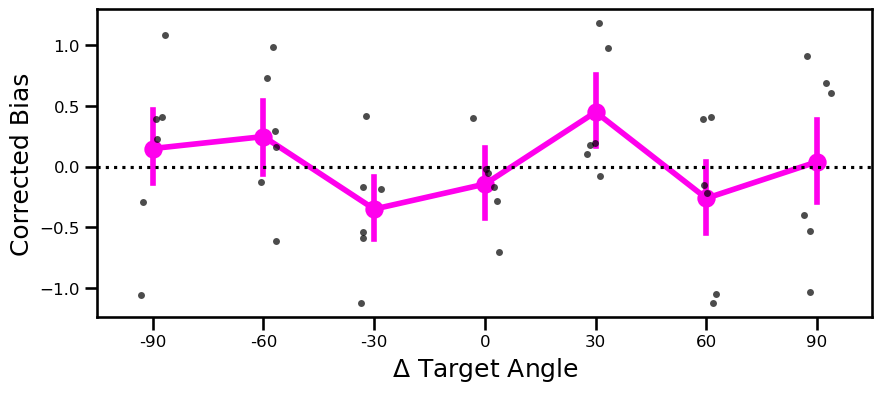

In [49]:
repulse_mask = (
    (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
    (~df['mt'].isna()) &
    (df['rt'] > 0.5) &  
    (df["target_angle_diff"].abs() <= 90) &
    (np.abs(df['theta_pv']) < 60)
)

df_repulse = df.loc[repulse_mask].copy()

subject_means_repulse = (
    df_repulse
    .groupby(['SN', 'target_angle_diff'])['corrected_repulse_theta_pv' ]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    # data=df_repulse,
    # to look at a single subject (comment)
    data = df_repulse.loc[df_repulse["SN"] == 6],
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

fig2, ax2 = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax2
)
sns.stripplot(
    data=subject_means_repulse,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax2
)
ax2.axhline(0, color='black', linestyle=':')
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')


# Plotting biases in use-dependent phase (using theta_pv)

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_39238/2364932934.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(N_finder, N_minus_targ=150)


Text(0, 0.5, 'Corrected Bias')

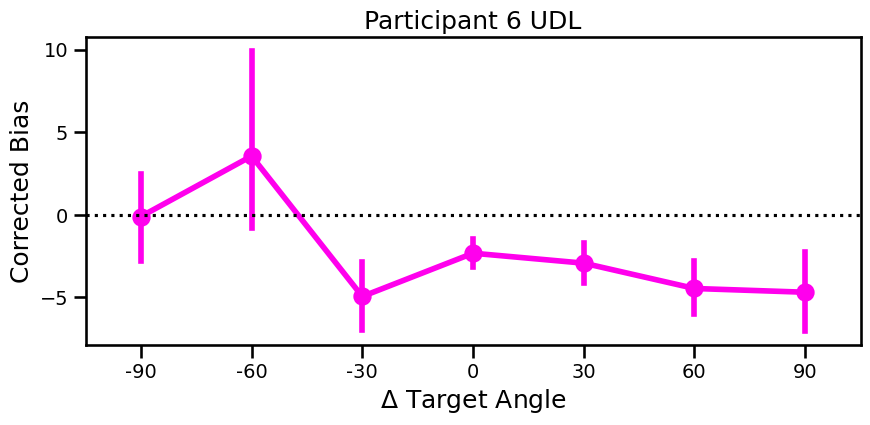

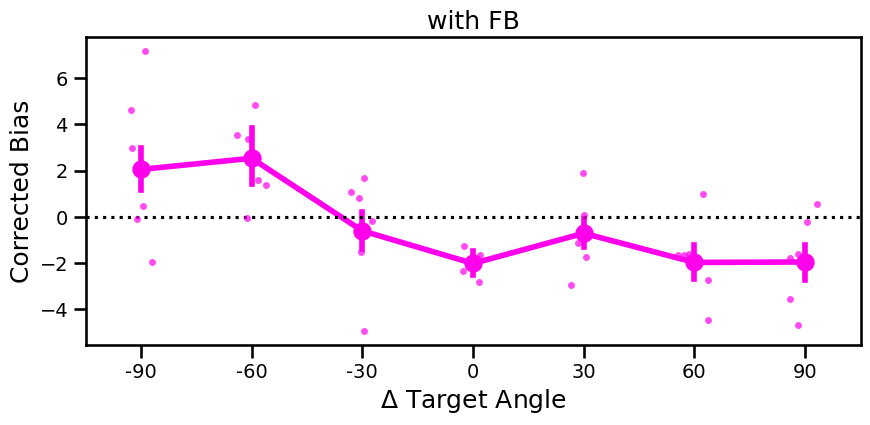

In [50]:
mask_udl = (
    (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1]) & 
    (~df['mt'].isna()) & 
    (df['rt'] > 0.500) & 
    (df['theta_pv'].abs() < 60)
)

df_udl = df.loc[mask_udl].copy()

df_udl_constrained = (
    df_udl
    .groupby('SN', as_index=False)
    .apply(N_finder, N_minus_targ=150)
    .reset_index(drop=True)
).copy()

df_udl_constrained = df_udl_constrained.loc[df_udl_constrained['feedback'] == 0]
## change to 'probe' == 1 

subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['corrected_udl_theta_pv'].mean().reset_index()

# plot graph for one participant
subject_num = 6
fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained[df_udl_constrained['SN']==subject_num],
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias') 
plt.title(f'Participant {subject_num} UDL')


# plot graph for group level 
fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    #color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

# sns.stripplot(
#     data=subject_means[subject_means['SN']==5],
#     x='target_angle_diff',
#     y='angle_error_corrected_udl',
#     color='red',
#     alpha=0.7,
#     jitter=0.15,
#     size=5,
#     ax=ax
# )

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.title('with FB')
## change the name of the x axis 
plt.ylabel('Corrected Bias') 

# plt.savefig('withFB.png', dpi=600, bbox_inches='tight')


## UDL by participant 

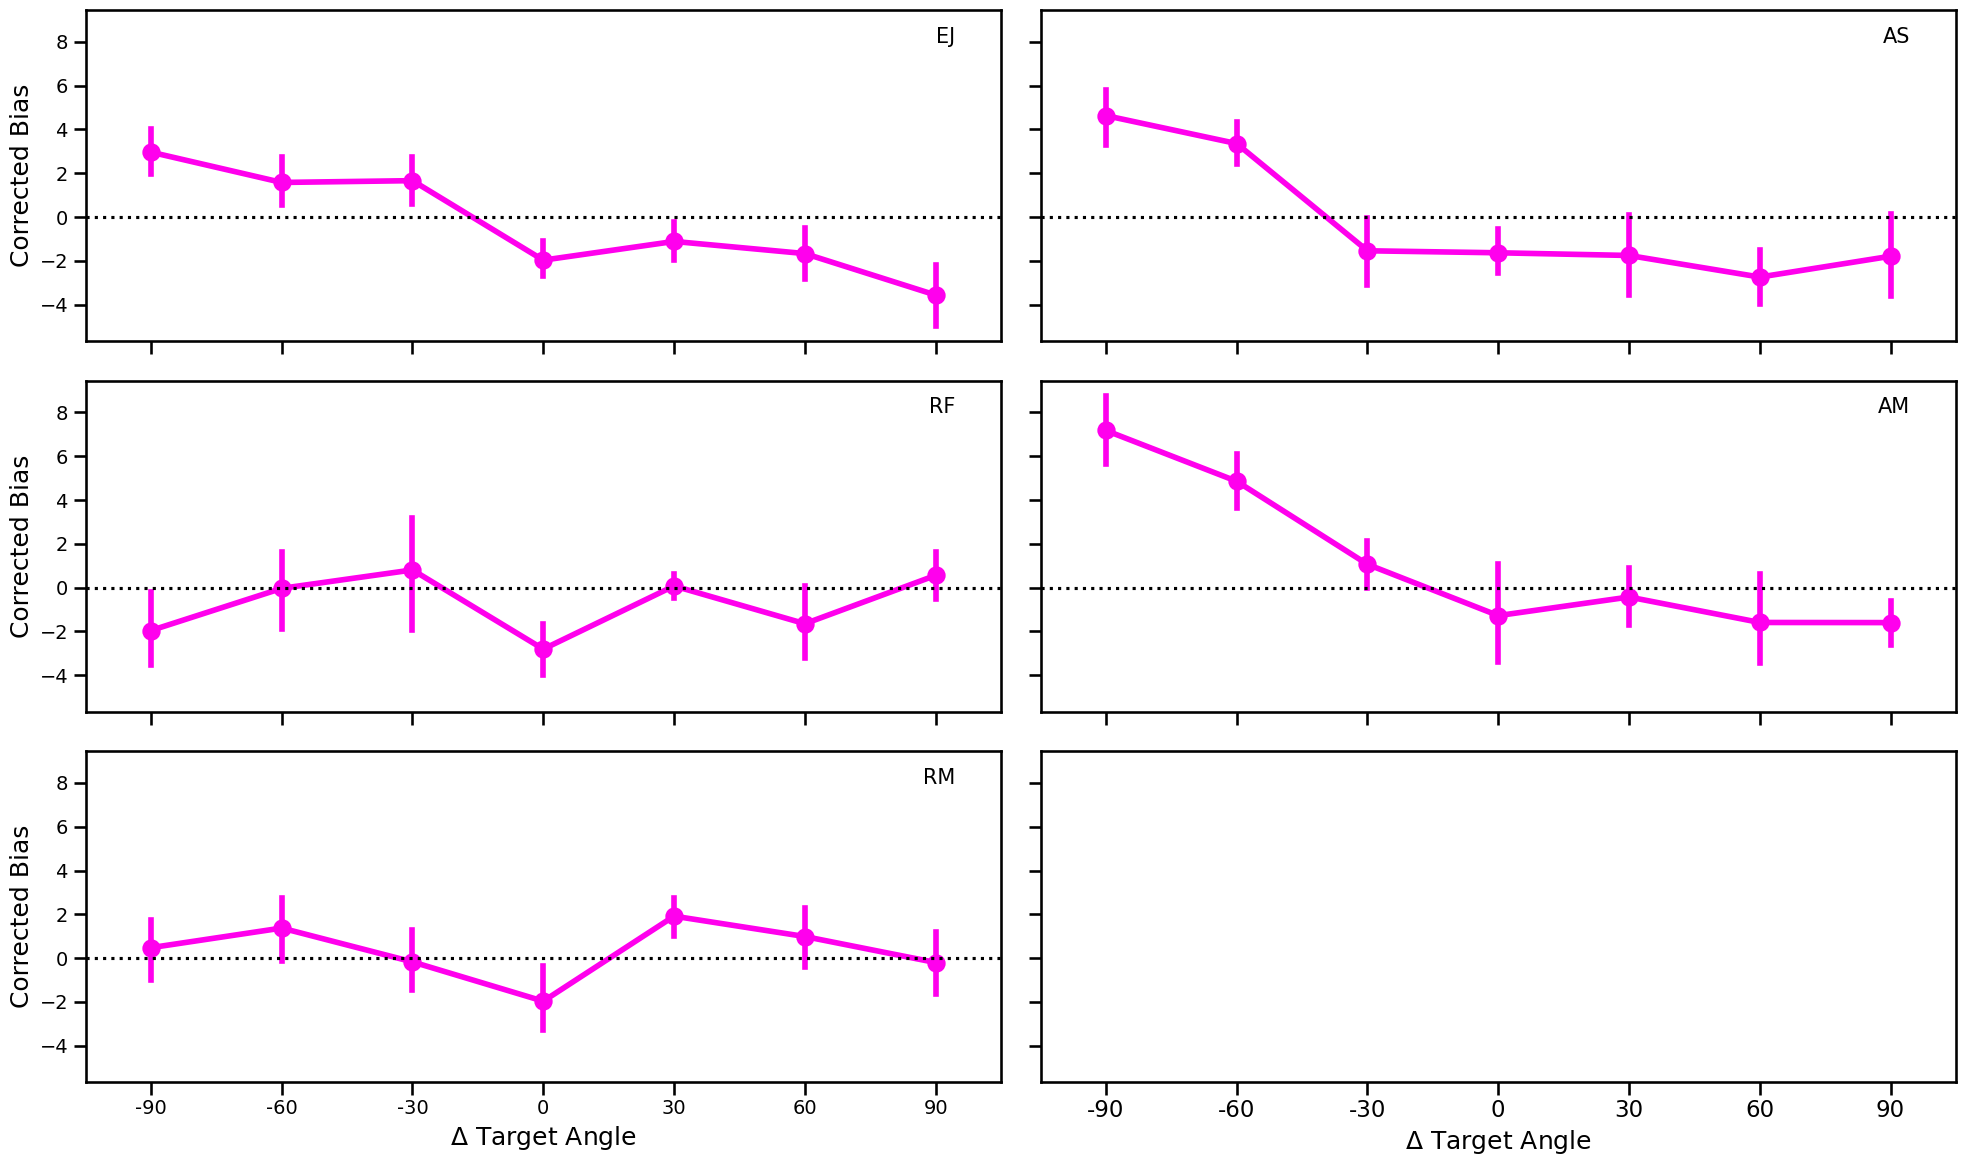

In [51]:
participants = sorted(df_udl_constrained['SN'].unique())
participant_names = ["EJ", "AS", "RF", "AM", "RM"]


fig, axes = plt.subplots(3, 2, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, subject_num, name in zip(axes, participants, participant_names):
    sns.pointplot(
        data=df_udl_constrained[df_udl_constrained['SN'] == subject_num],
        x='target_angle_diff',
        y='corrected_udl_theta_pv',
        estimator='mean',
        errorbar=('ci', 95),
        ax=ax
    )
    
    ax.axhline(0, color='black', linestyle=':')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylabel('Corrected Bias')

    # participant label in upper right corner
    ax.text(
        0.95, 0.95, name,
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=15,
        #fontweight='bold'
    )

# remove unused subplot
for ax in axes[len(participants):]:
    ax.remove()

axes[-2].set_xlabel(r'$\Delta$ Target Angle')
axes[-1].set_xlabel(r'$\Delta$ Target Angle')

plt.tight_layout()
#plt.savefig('partwithFB.png', dpi=600, bbox_inches='tight')

plt.show()

## UDL with raw theta_pv 

Text(0, 0.5, 'Raw Bias')

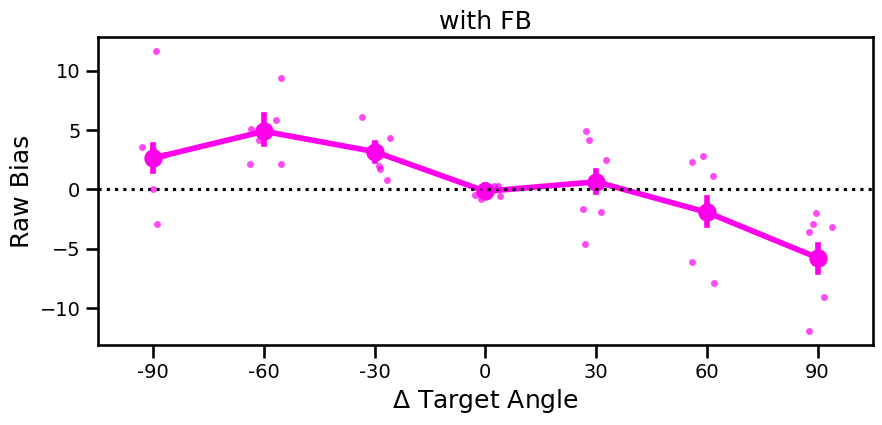

In [52]:
subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['theta_pv'].mean().reset_index()

# plot graph for group level 
fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='theta_pv',
    #color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

# sns.stripplot(
#     data=subject_means[subject_means['SN']==5],
#     x='target_angle_diff',
#     y='angle_error_corrected_udl',
#     color='red',
#     alpha=0.7,
#     jitter=0.15,
#     size=5,
#     ax=ax
# )

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
## change the name of the x axis 
plt.title('with FB')

plt.ylabel('Raw Bias') 


# Plot UDL using Target Angle & Inward Bias 

Text(0, 0.5, 'Inward Bias')

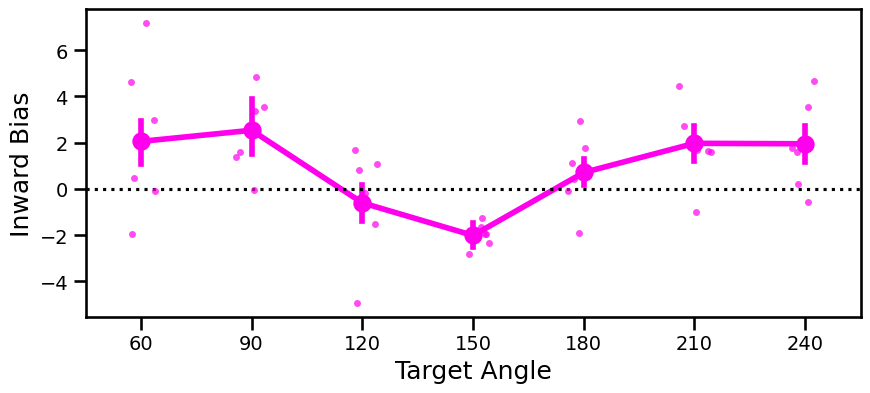

In [53]:
df_udl_constrained["inward_bias"] = df_udl_constrained["corrected_udl_theta_pv"].copy()

# Flip sign for targets > repeated target (150)
df_udl_constrained.loc[df_udl_constrained["target_angle"] > 150, "inward_bias"] *= -1

subject_means = df_udl_constrained.groupby(['SN', 'target_angle'])['inward_bias'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle',
    y='inward_bias',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
sns.stripplot(
    data=subject_means,
    x='target_angle',
    y='inward_bias',
    # color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'Target Angle')
plt.ylabel('Inward Bias')

## Inward bias vs probe distance 

Text(0, 0.5, 'Inward Bias')

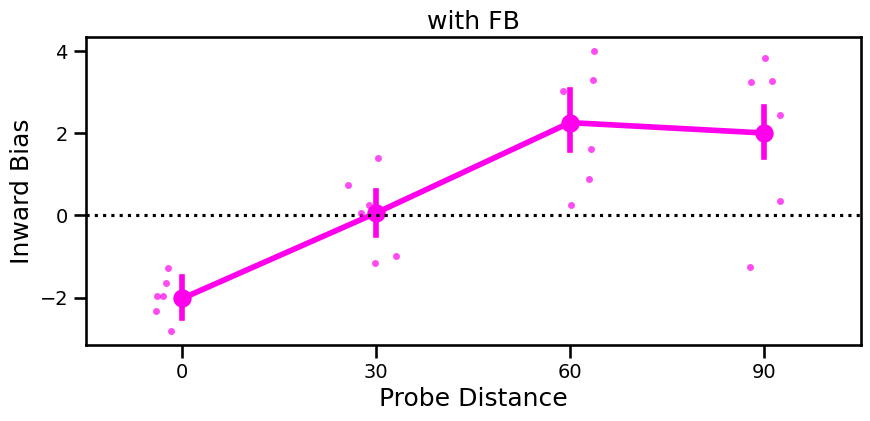

In [54]:
df_udl_constrained["probe_distance"] = df_udl_constrained["target_angle_diff"].abs()

subject_means = df_udl_constrained.groupby(['SN', 'probe_distance'])['inward_bias'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='probe_distance',
    y='inward_bias',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
sns.stripplot(
    data=subject_means,
    x='probe_distance',
    y='inward_bias',
    #color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.title('with FB')
plt.xlabel(r'Probe Distance')
plt.ylabel('Inward Bias')

#plt.savefig('inwardFB.png', dpi=600, bbox_inches='tight')

## checking the validity of the bias calculation 

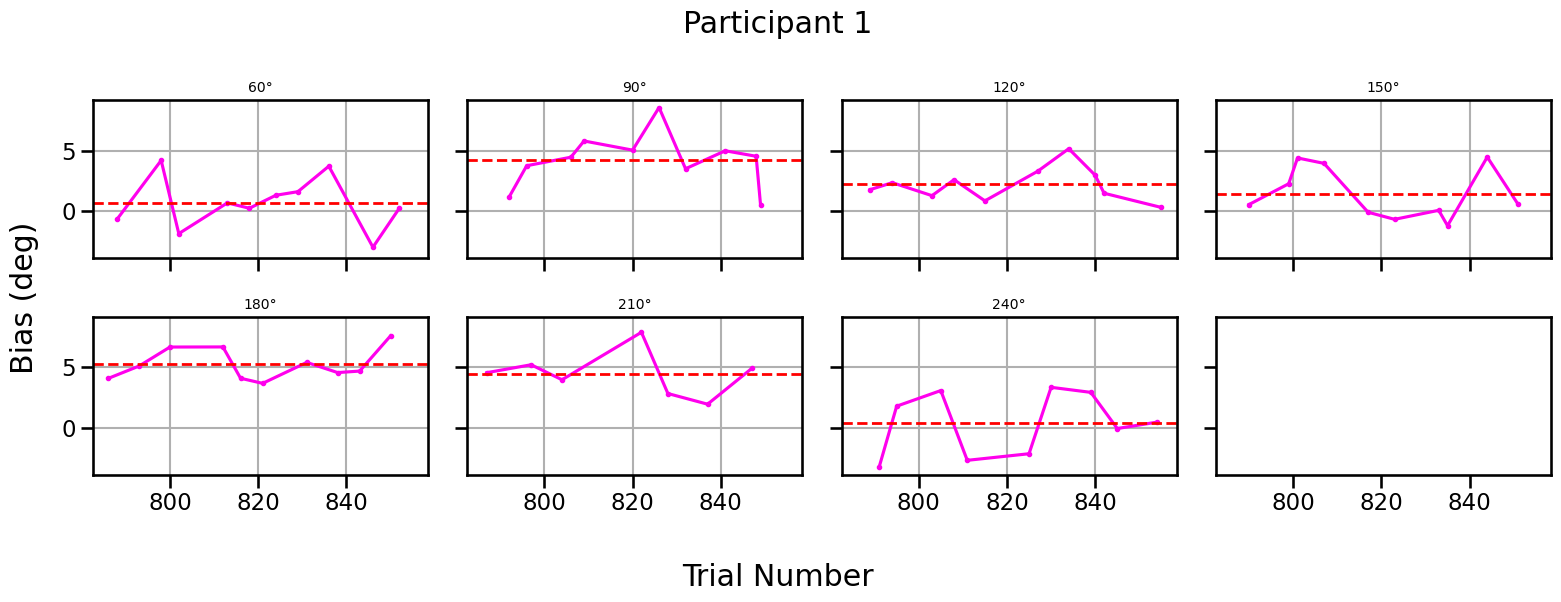

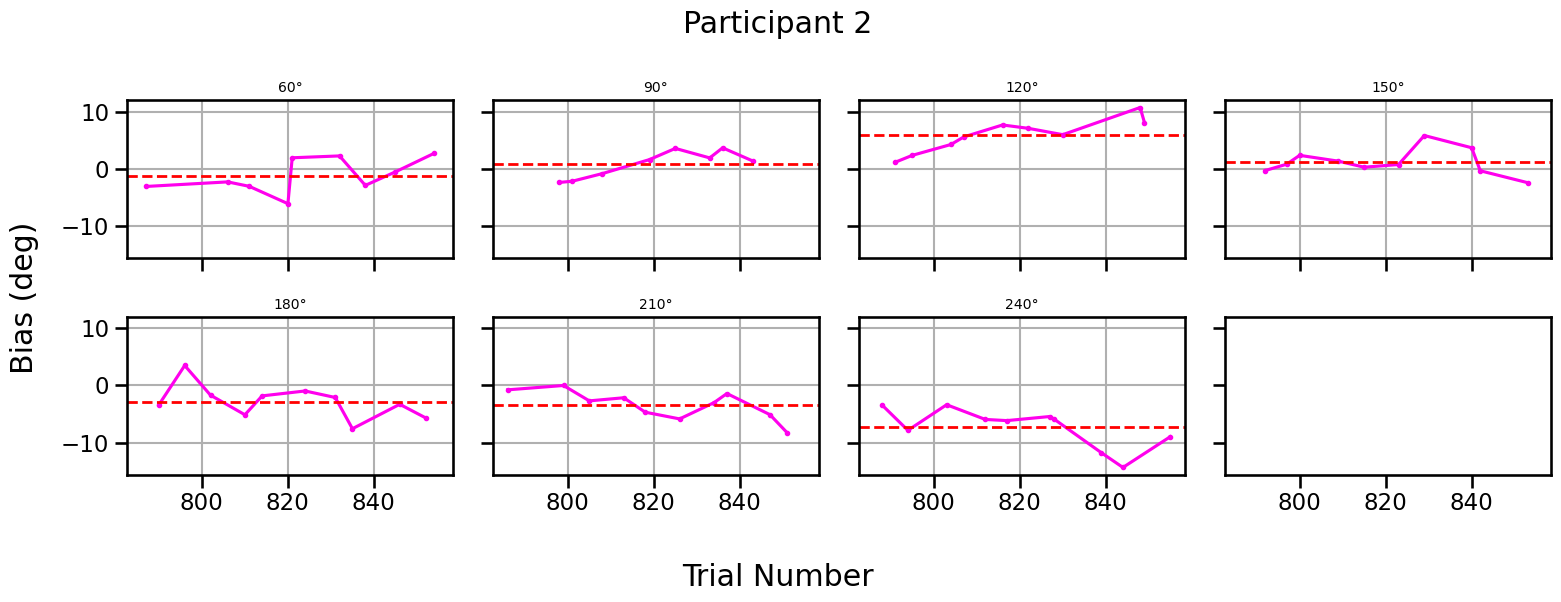

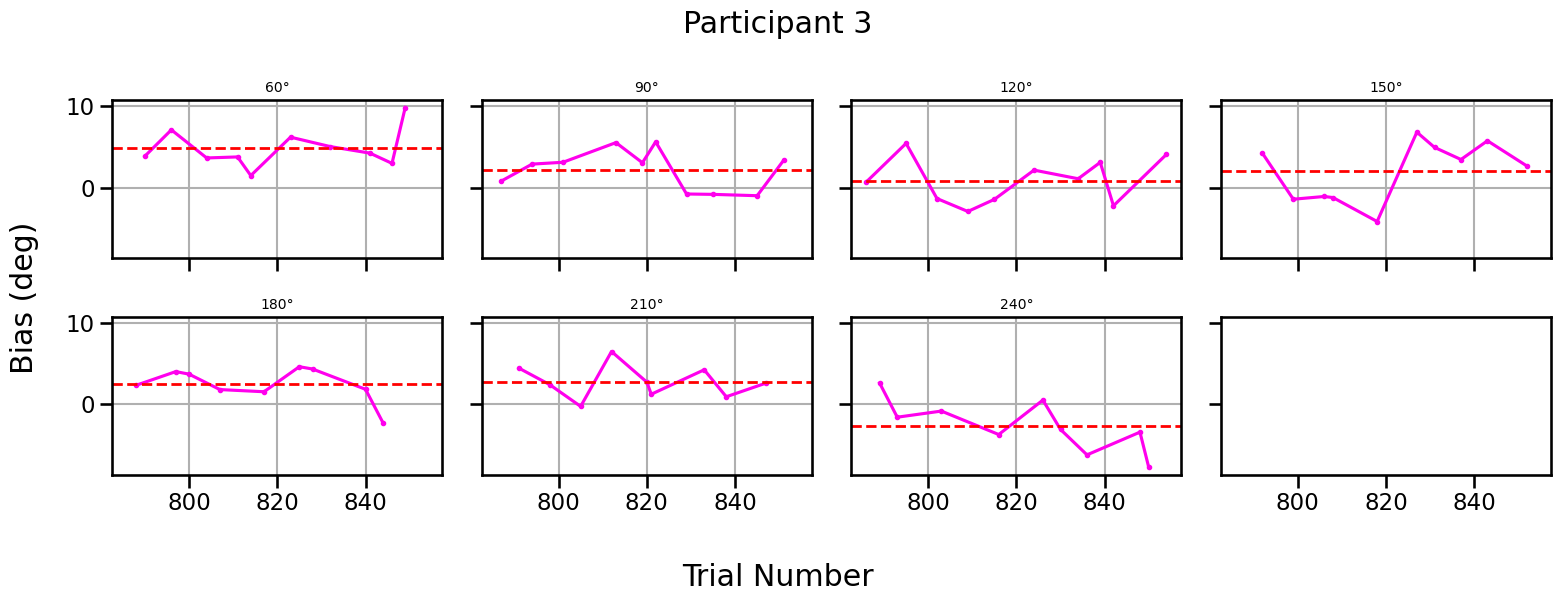

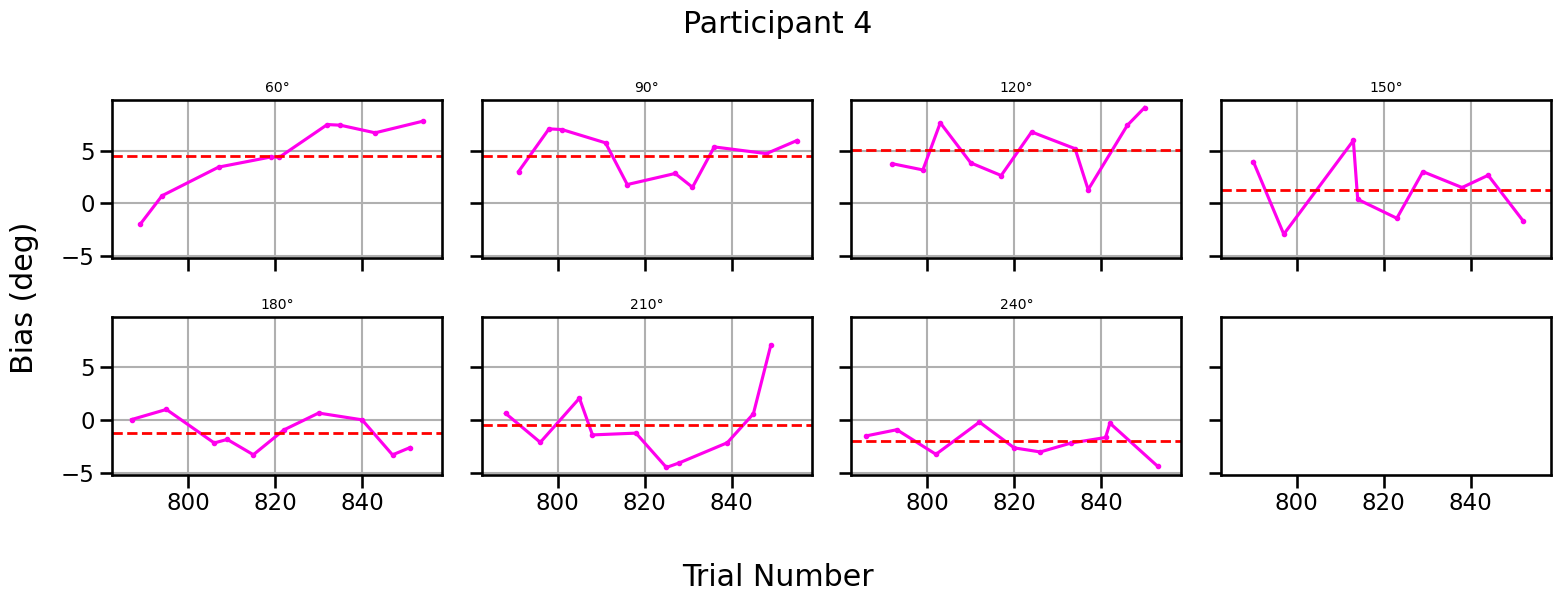

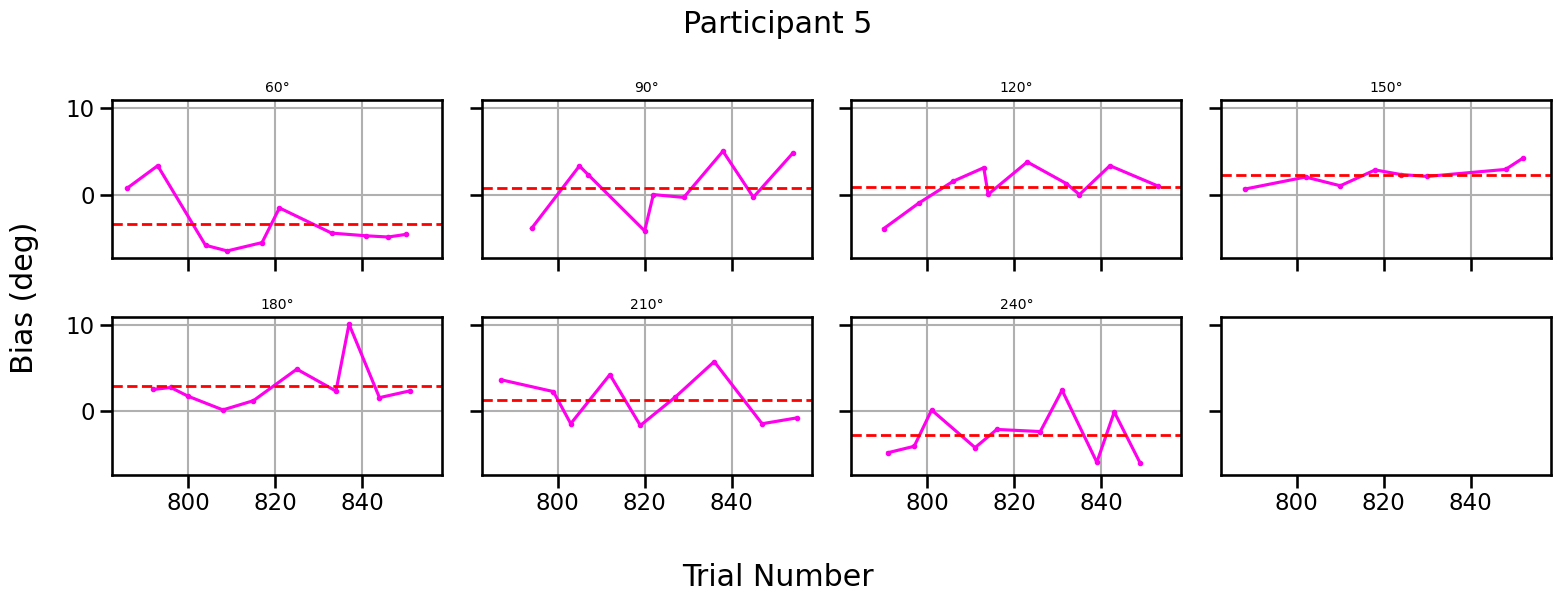

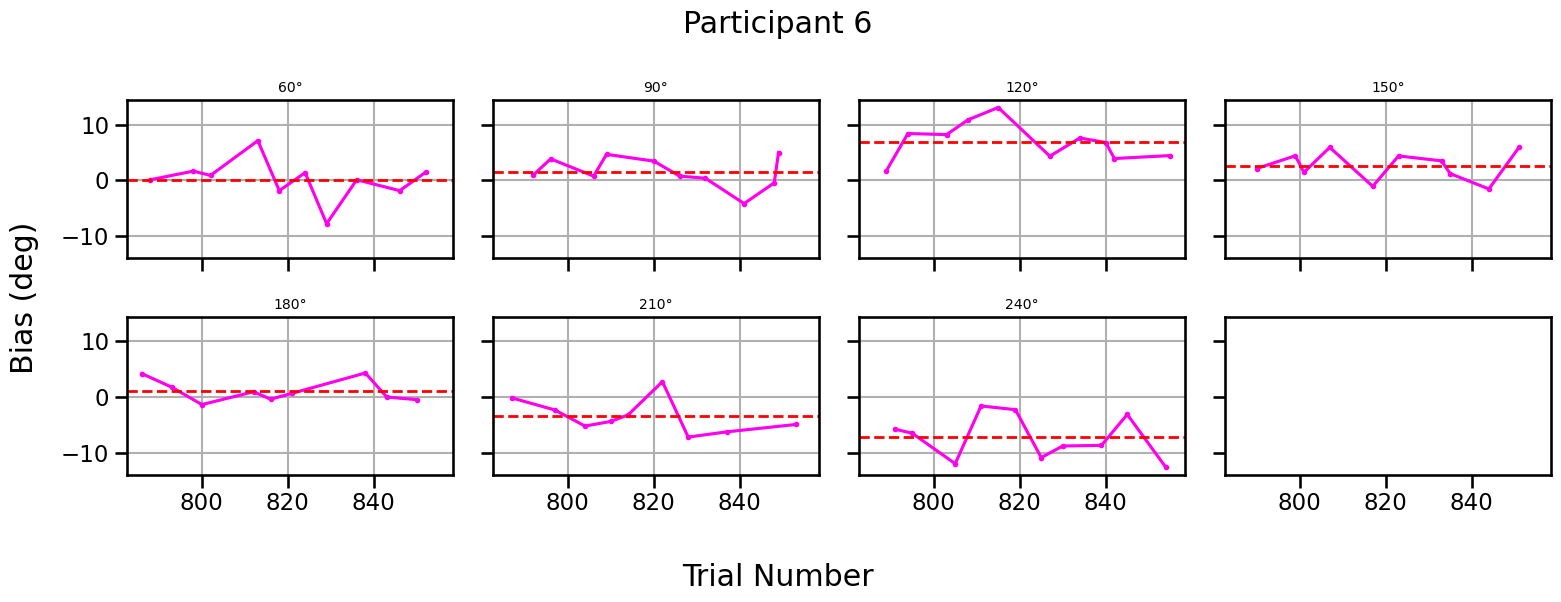

In [55]:
mask_udl = (
    (df['TN'] >= epochs['udl_baseline_noFB'][0]) & (df['TN'] <= epochs['udl_baseline_noFB'][1])
    & (~df['mt'].isna()) & (df['rt'] > 0.500) & (df['theta_pv'].abs() < 60))

df_udl_bias = df.loc[mask_udl]

target_angles = sorted(df_udl_bias['target_angle'].unique())

for sn in df_udl_bias["SN"].unique():

    ncols = 4
    nrows = int(round(len(target_angles) / ncols,))

    fig, axes = plt.subplots(nrows, ncols,figsize=(4*ncols, 3*nrows),sharex=True,sharey=True)
    axes = np.array(axes).flatten()

    for ax, ta in zip(axes, target_angles):
        df_sn = (df_udl_bias[(df_udl_bias["SN"] == sn) &(df_udl_bias["target_angle"] == ta)].sort_values("TN"))

        ax.plot(df_sn["TN"],df_sn["theta_pv"],'o-',markersize=3)

        mean_val = df_sn["theta_pv"].mean()

        ax.axhline(y=mean_val,color='r',linestyle='--',linewidth=2)

        ax.set_title(f"{ta}°", fontsize=10)
        ax.grid(True)

    fig.suptitle(f"Participant {sn}")
    fig.supxlabel("Trial Number")
    fig.supylabel("Bias (deg)")

    plt.tight_layout()
    plt.show()

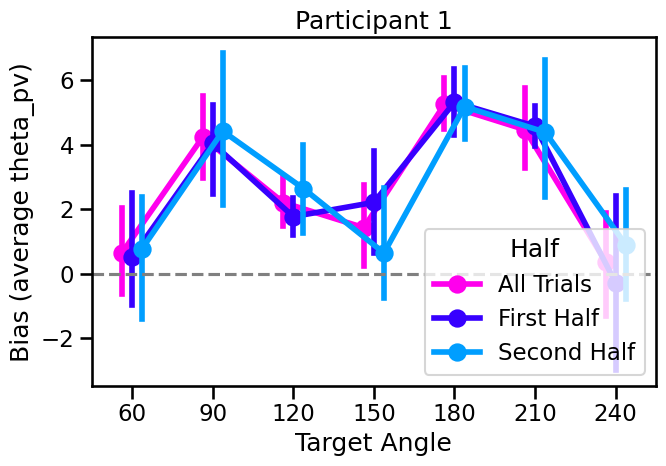

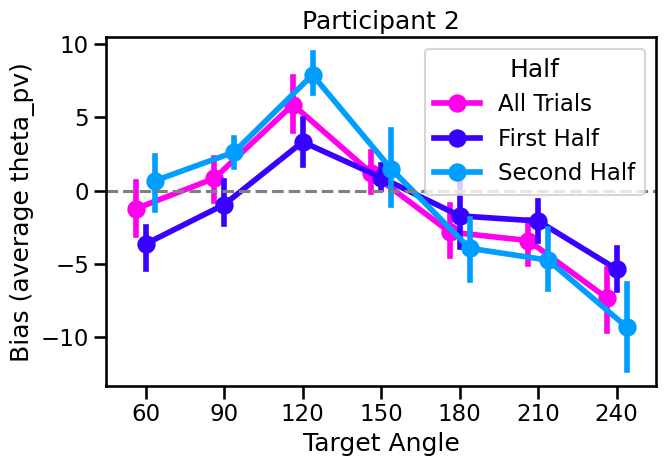

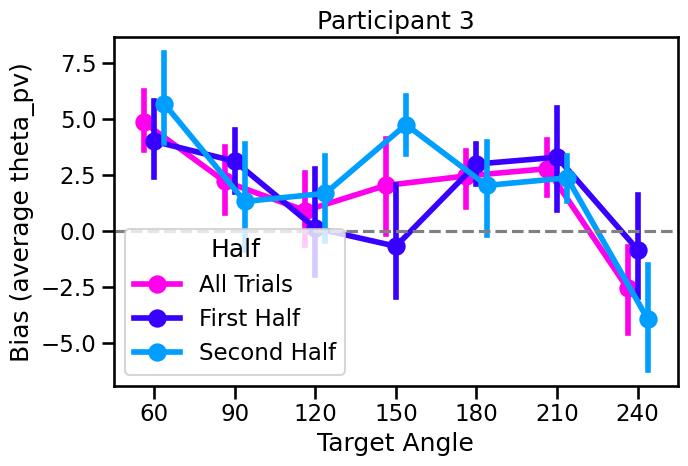

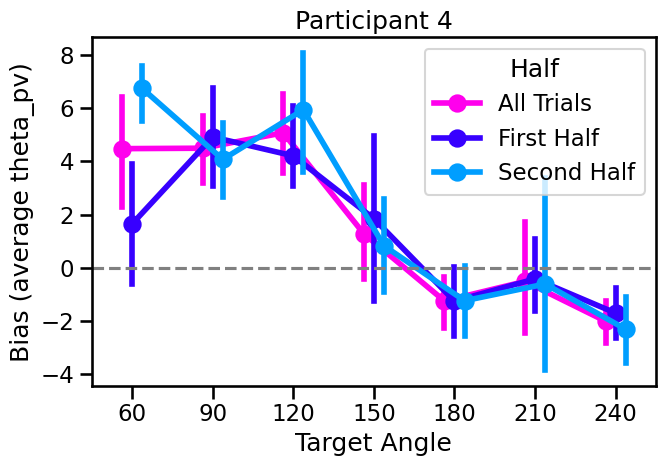

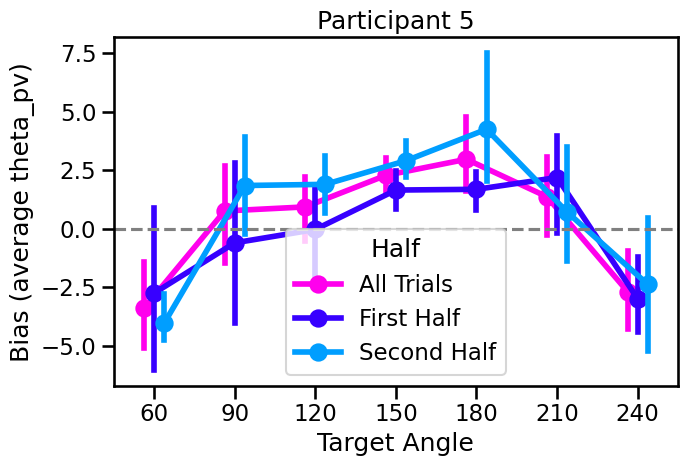

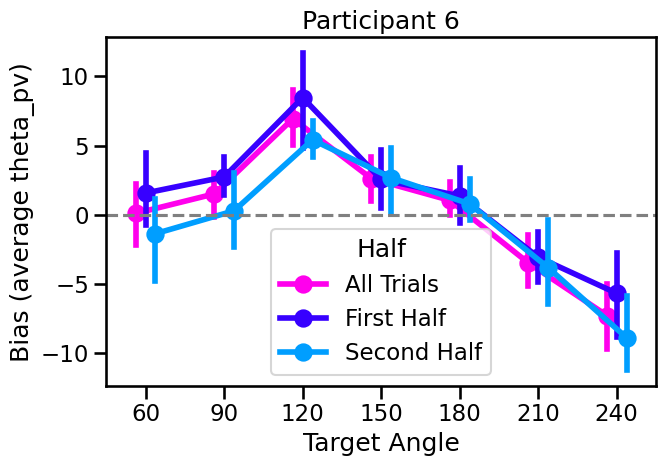

In [56]:
# for each participant, look their average bias for each target_angle and  bias split into the first and second half. 
# graph for each partipant that has the target angles on the x axis, and on the y axis is bias

# calcualted from the 'udl_baseline_noFB' phase (i.e. the second baseline trial) --> 70 trials, 10 trials per target angle 

mask_udl = (
    (df['TN'] >= epochs['udl_baseline_noFB'][0]) & (df['TN'] <= epochs['udl_baseline_noFB'][1])
    & (~df['mt'].isna()) & (df['rt'] > 0.500) & (df['theta_pv'].abs() < 60))

df_udl_bias = df.loc[mask_udl]

target_angles = sorted(df_udl_bias["target_angle"].unique())

for sn in df_udl_bias["SN"].unique():

    df_sn = df_udl_bias[df_udl_bias["SN"] == sn].copy()
    dfs = []

    for angle in target_angles:

        df_angle = df_sn[df_sn["target_angle"] == angle].copy()

        n = len(df_angle)
        half = n // 2

        first = df_angle.iloc[:half].copy()
        second = df_angle.iloc[half:].copy()

        df_angle["Half"] = "All Trials"
        first["Half"] = "First Half"
        second["Half"] = "Second Half"

        dfs.extend([df_angle, first, second])

    plot_df = pd.concat(dfs, ignore_index=True)

    plt.figure(figsize=(7,5))

    sns.pointplot(
        data=plot_df,
        x="target_angle",
        y="theta_pv",
        hue="Half",
        estimator="mean",
        errorbar=("ci", 95),
        dodge=0.25,
        linestyles="-"
    )

    plt.axhline(0, color='gray', linestyle='--')
    plt.xlabel("Target Angle")
    plt.ylabel("Bias (average theta_pv)")
    plt.title(f"Participant {sn}")
    plt.tight_layout()
    plt.show()

# Comparison of theta_40, theta_100, theta_pv, and theta_end 
## REPULSE 

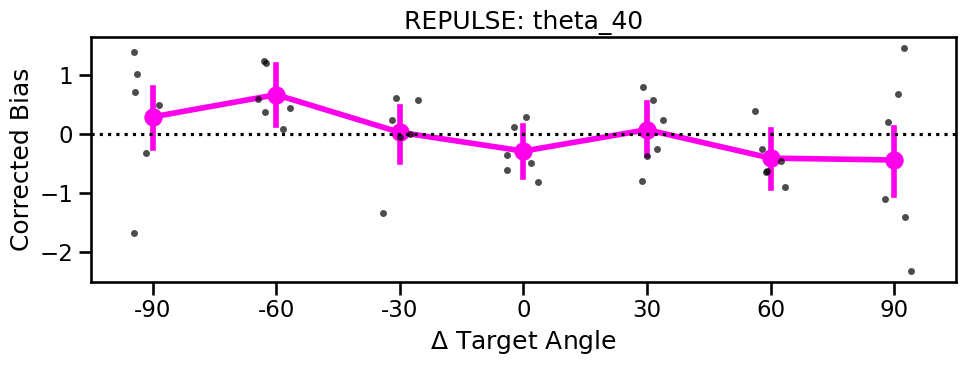

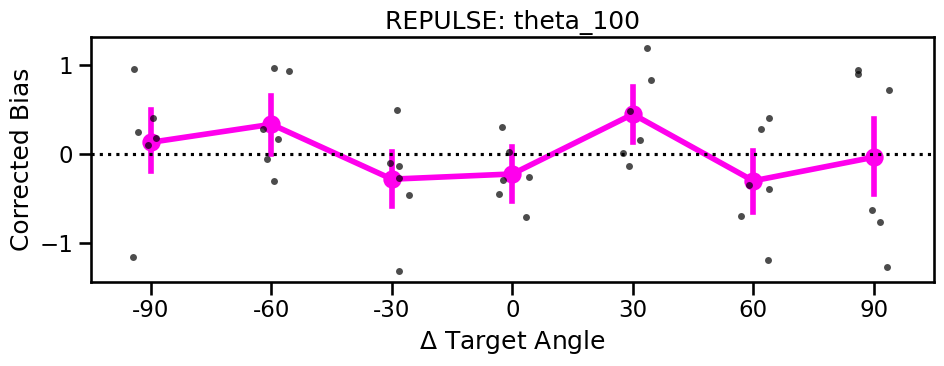

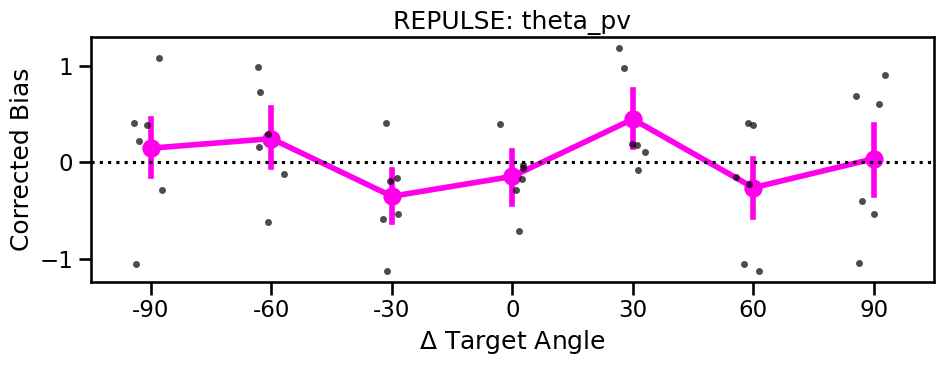

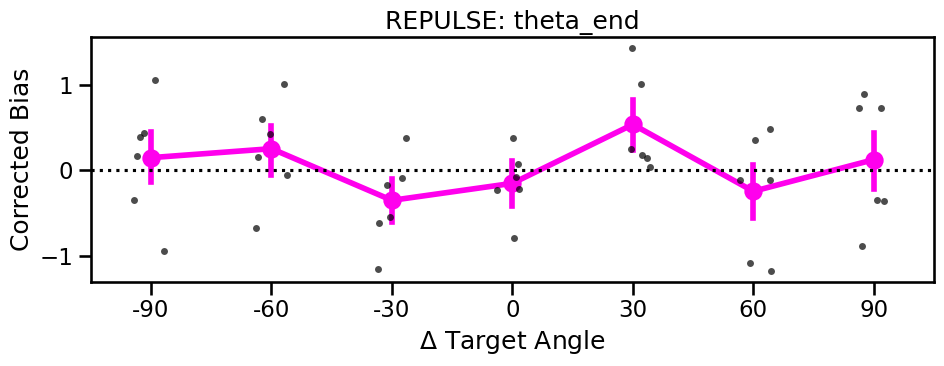

In [57]:
## plotting function? 
def plot_bias(df_plot, y_col, title):
    '''
    a plotting function that takes in a data frame, the y column (corrected angle), and the title for the graph 
    '''
    subject_means = (
        df_plot
        .groupby(["SN", "target_angle_diff"])[y_col]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10,4))

    sns.pointplot(
        data=df_plot,
        x="target_angle_diff",
        y=y_col,
        estimator="mean",
        errorbar=("ci",95),
        ax=ax
    )

    sns.stripplot(
        data=subject_means,
        x="target_angle_diff",
        y=y_col,
        color="black",
        alpha=0.7,
        jitter=0.15,
        size=5,
        ax=ax
    )

    ax.axhline(0, color="black", linestyle=":")
    ax.set_xlabel(r"$\Delta$ Target Angle")
    ax.set_ylabel("Corrected Bias")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

for angle in angle_cols:
    plot_bias(
        df_repulse,
        y_col=f"corrected_repulse_{angle}",
        title=f"REPULSE: {angle}"
    )

## UDL

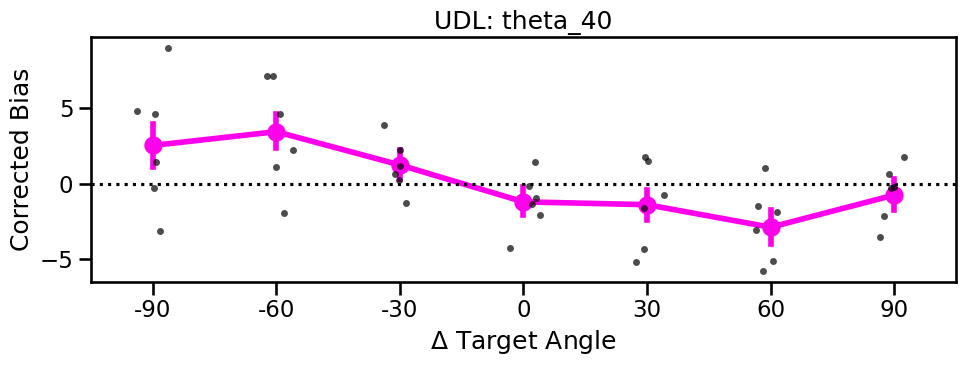

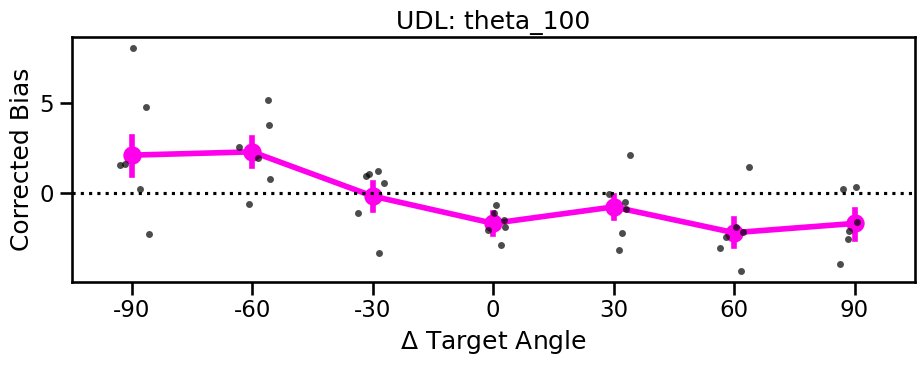

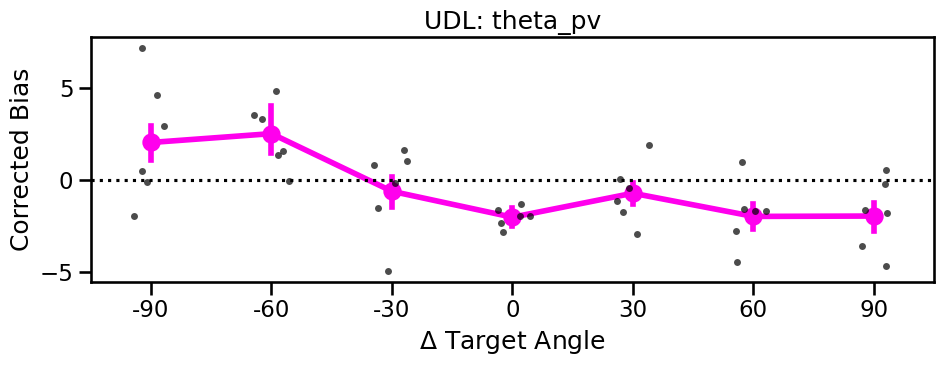

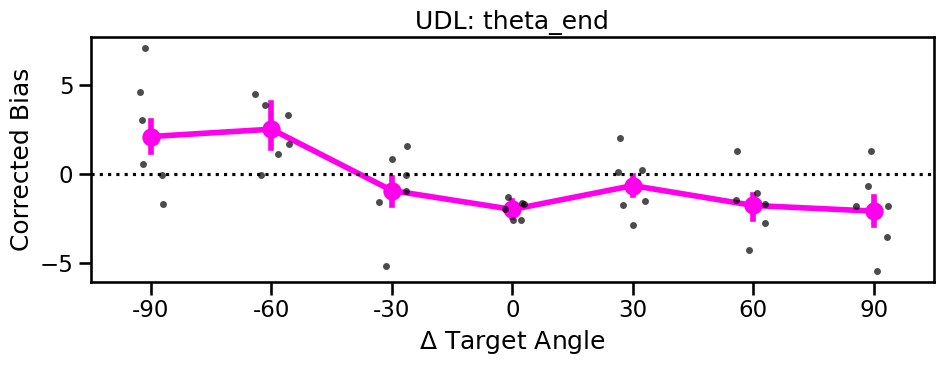

In [58]:
for angle in angle_cols:
    plot_bias(
        df_udl_constrained,
        y_col=f"corrected_udl_{angle}",
        title=f"UDL: {angle}"
    )

## Movement Speed (Peak Velocity)

(Wong & Haith, 2017)
slower mt = more pronounced bias

‘Fast’ (peak velocity, **0.8–1.5 m/s**)

‘Slow’ (peak velocity, **0.3–0.7 m/s**)

look at the peak velocity per participant, both WITH FB and WITHOUT FB 

1. create histogram for each participant showing the distribution of the peak velocity. 
+ findings: 
  + some participants are VERY FAST (i.e. participant 2 -- abby LOL)

2. PER participant: plot the corrected bias (lets do only theta_pv) for SLOW PV, FAST PV, and all PV. This is for both the REPULSE and UDL phase 

3. Group level: REPULSE bias and UDL bias during slow, fast, and all PV. 

### Distributions (histogram) of peak velocity 

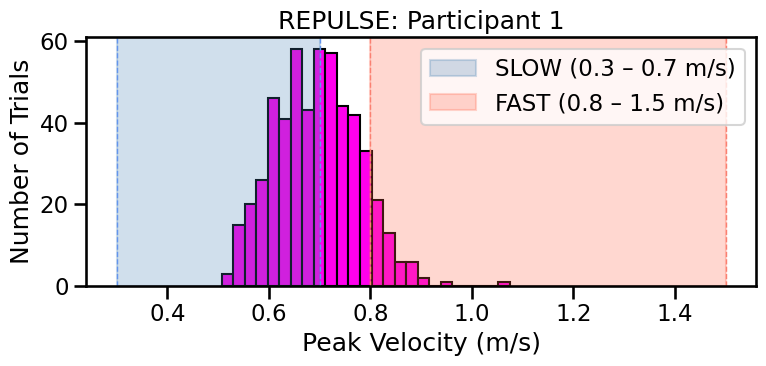

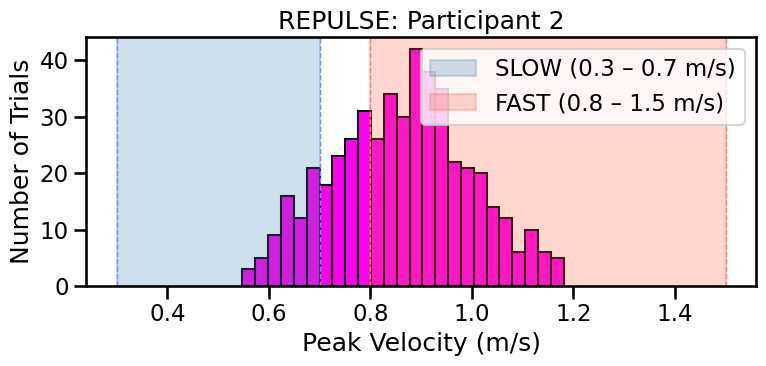

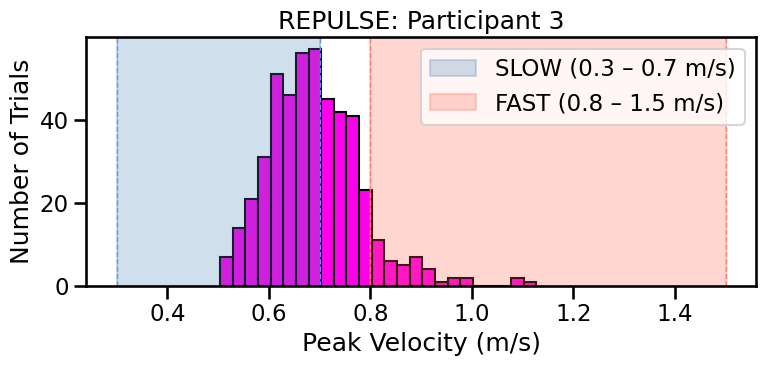

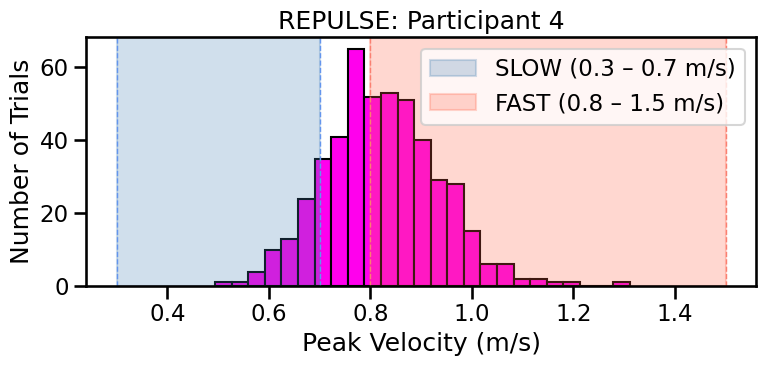

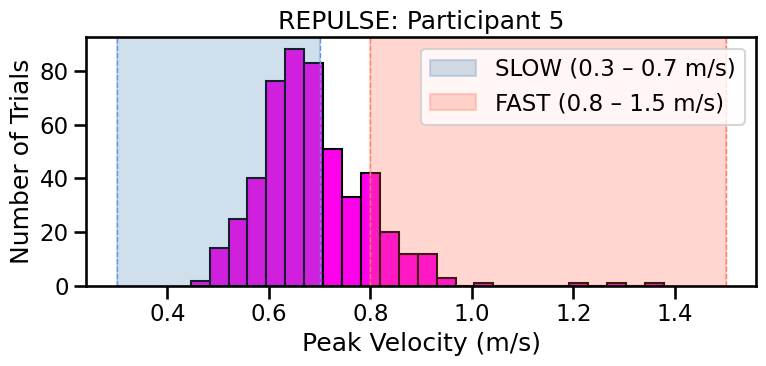

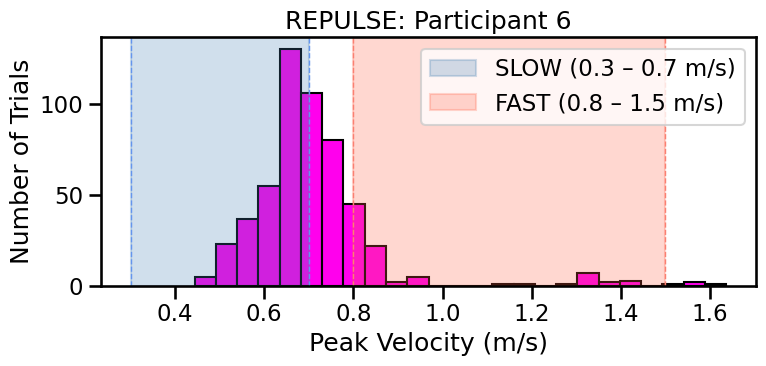

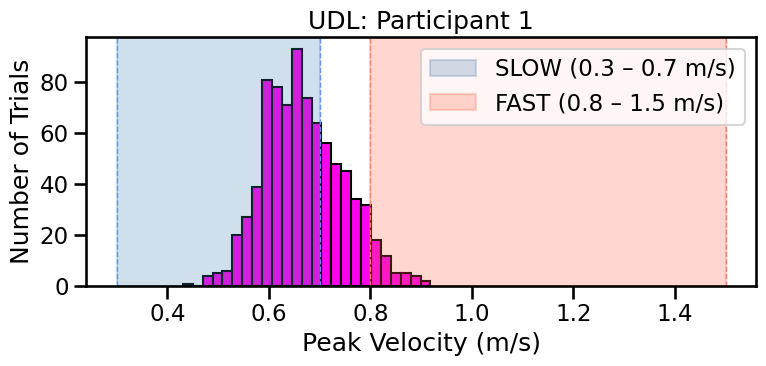

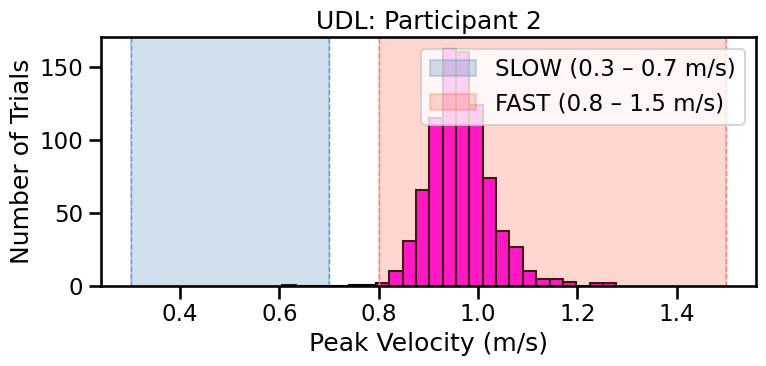

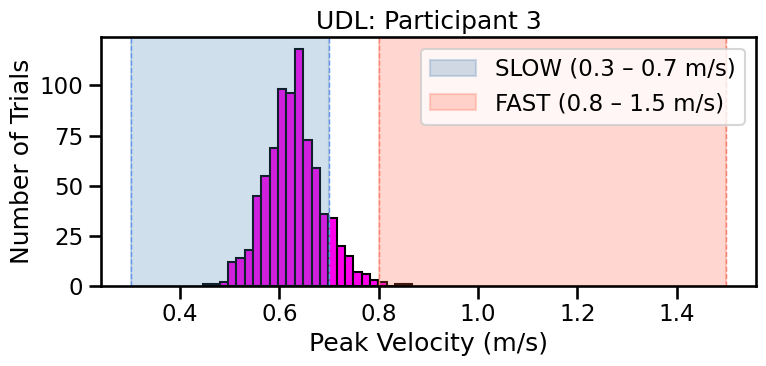

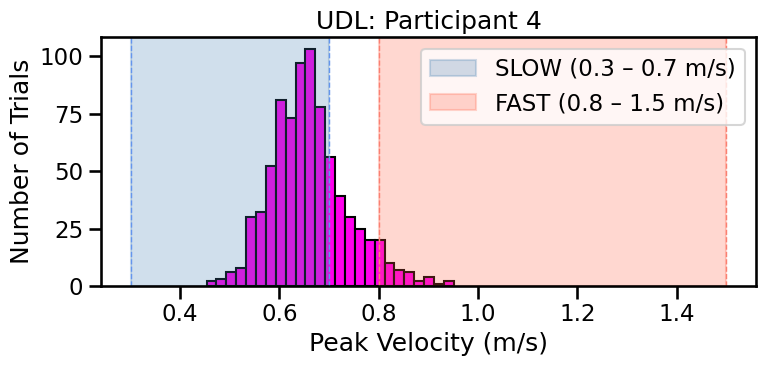

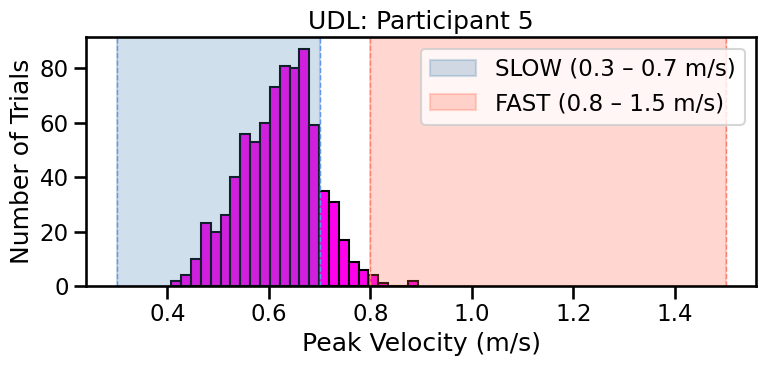

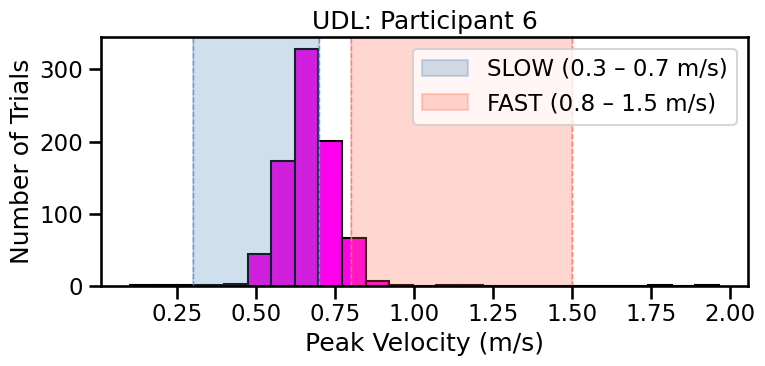

In [59]:
subjects = sorted(df["SN"].unique())

def plot_peak_velocity_histograms(df, phase_name, bins):
    """
    plotting function for peak velocity histograms for each participant; 
    regions for 'FAST' and 'SLOW' are indicated in red and blue respectively
    """
    for sn in subjects:

        pv = df.loc[df["SN"] == sn, "peak_vel"].dropna()

        fig, ax = plt.subplots(figsize=(8, 4))

        # plot histogram
        ax.hist(
            pv,
            bins=bins,
            edgecolor="black")

        # SLOW shaded region
        ax.axvspan(
            0.3,
            0.7,
            alpha=0.25,
            color="steelblue",
            label="SLOW (0.3 – 0.7 m/s)")

        # FAST shaded region
        ax.axvspan(
            0.8,
            1.5,
            alpha=0.25,
            color="tomato",
            label="FAST (0.8 – 1.5 m/s)")

        # Region boundaries
        ax.axvline(0.3, color="cornflowerblue", linestyle="--", linewidth=1)
        ax.axvline(0.7, color="cornflowerblue", linestyle="--", linewidth=1)

        ax.axvline(0.8, color="salmon", linestyle="--", linewidth=1)
        ax.axvline(1.5, color="salmon", linestyle="--", linewidth=1)

        ax.set_title(f"{phase_name}: Participant {sn}")
        ax.set_xlabel("Peak Velocity (m/s)")
        ax.set_ylabel("Number of Trials")

        ax.legend()
        plt.tight_layout()
        plt.show()


plot_peak_velocity_histograms(df_repulse, "REPULSE", 25)
plot_peak_velocity_histograms(df_udl, "UDL", 25)

### Bias per participant (SLOW, FAST, ALL)
#### not really informative...

In [60]:
# create a "pv_category" column that stores whether a reach is slow or fast 
df["pv_category"] = np.nan
df.loc[(df["peak_vel"] >= 0.3) & (df["peak_vel"] <= 0.7),"pv_category"] = "SLOW"
df.loc[(df["peak_vel"] >= 0.8) & (df["peak_vel"] <= 1.5),"pv_category"] = "FAST"

# create dfs for ALL pvs, slow pvs, and fast pvs 
df_repulse = df.loc[repulse_mask]
df_repulse_slow = df_repulse[df_repulse["pv_category"] == "SLOW"]
df_repulse_fast = df_repulse[df_repulse["pv_category"] == "FAST"]

df_udl = df.loc[mask_udl]
df_udl_constrained = (
    df_udl
    .groupby('SN', as_index=False)
    .apply(N_finder, N_minus_targ=150)
    .reset_index(drop=True)
)

df_udl_constrained = df_udl_constrained.loc[df_udl_constrained['feedback'] == 0]
df_udl_constrained_slow = df_udl_constrained[df_udl_constrained["pv_category"] == "SLOW"]
df_udl_constrained_fast = df_udl_constrained[df_udl_constrained["pv_category"] == "FAST"]

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_39238/2299444119.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SLOW' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[(df["peak_vel"] >= 0.3) & (df["peak_vel"] <= 0.7),"pv_category"] = "SLOW"
/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_39238/2299444119.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(N_finder, N_minus_targ=150)


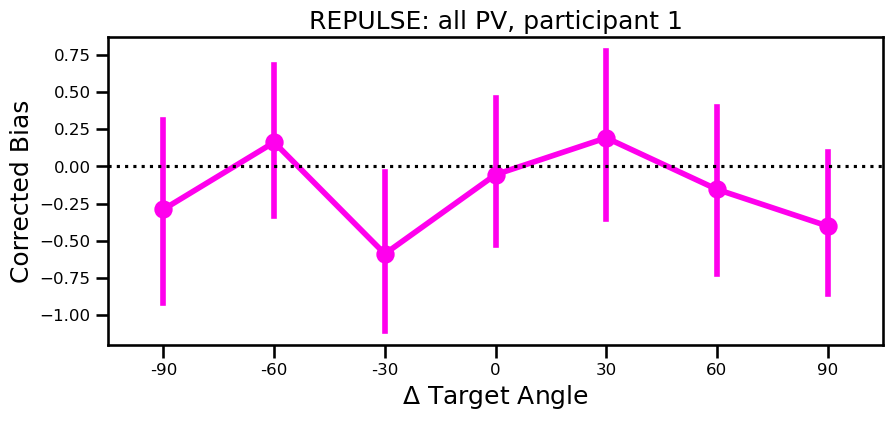

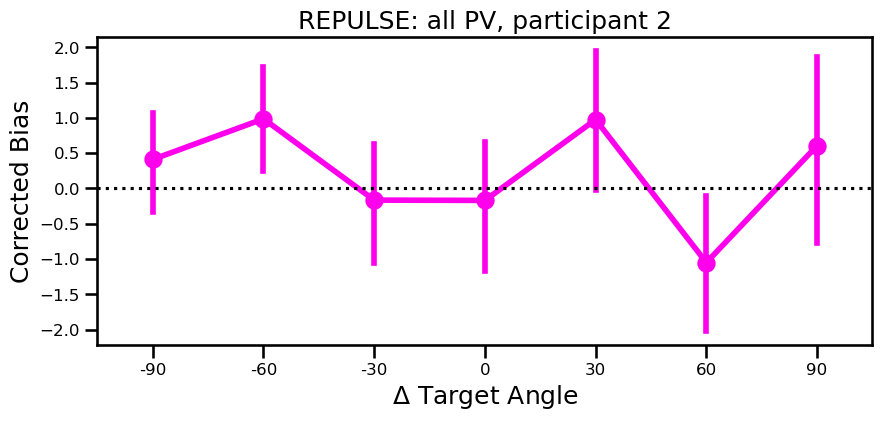

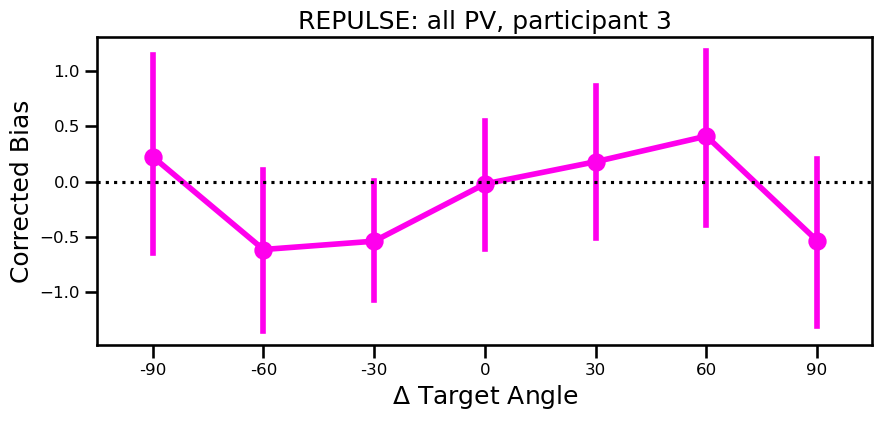

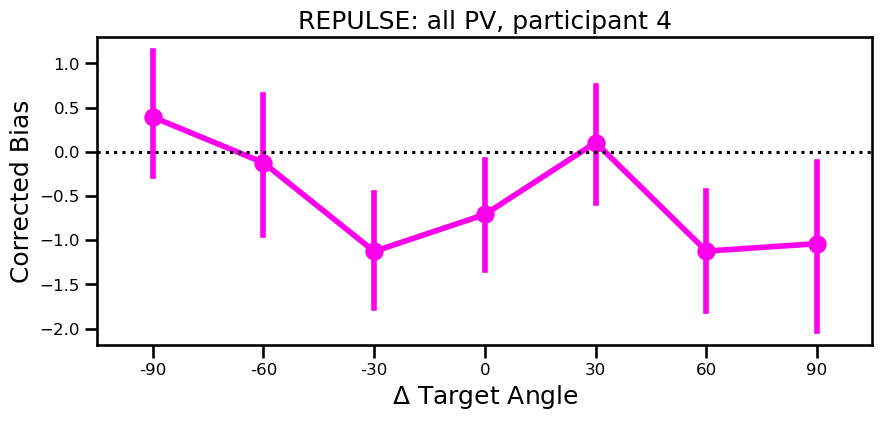

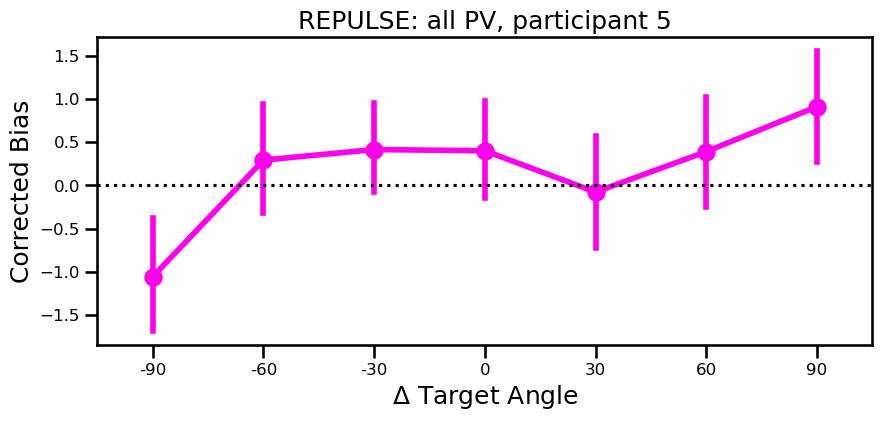

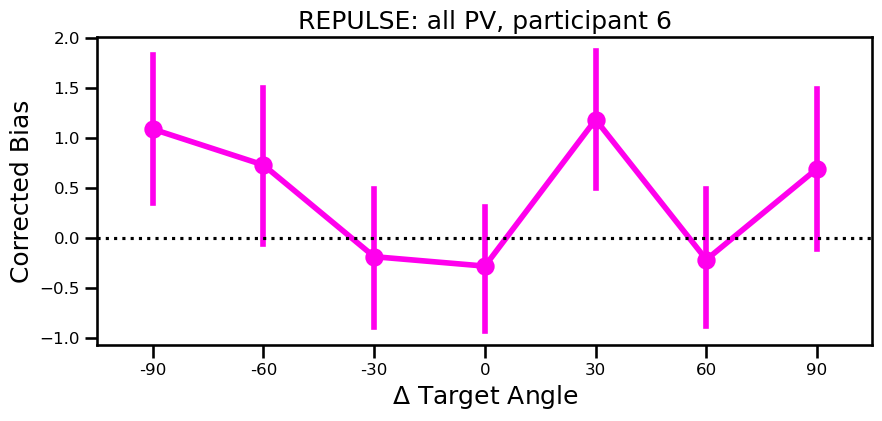

In [61]:
for sn in df_repulse["SN"].unique():
    df_sn = df_repulse[df_repulse["SN"] == sn]

    fig, ax = plt.subplots(figsize=(10,4))
    sns.pointplot(
        data=df_sn,
        x='target_angle_diff',
        y='corrected_repulse_theta_pv',
        estimator='mean',
        errorbar=('ci',95),
        #color='black',
        ax=ax)

    
    ax.axhline(0, color='black', linestyle=':')
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    plt.title(f"REPULSE: all PV, participant {sn}")
    plt.xlabel(r'$\Delta$ Target Angle')
    plt.ylabel('Corrected Bias')

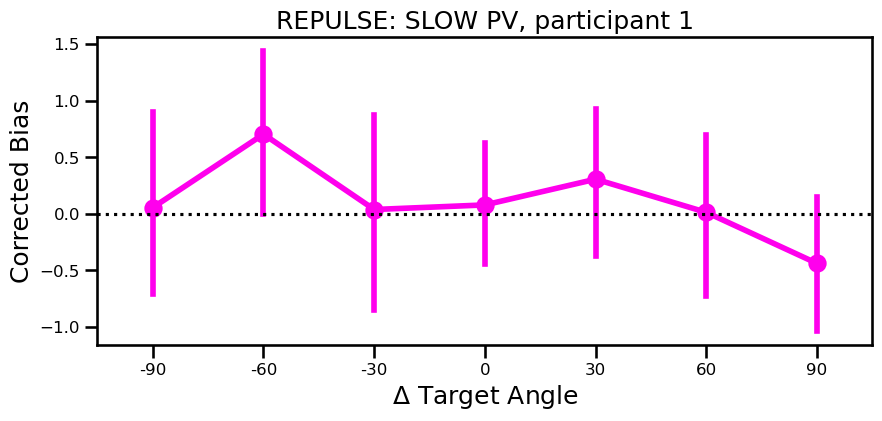

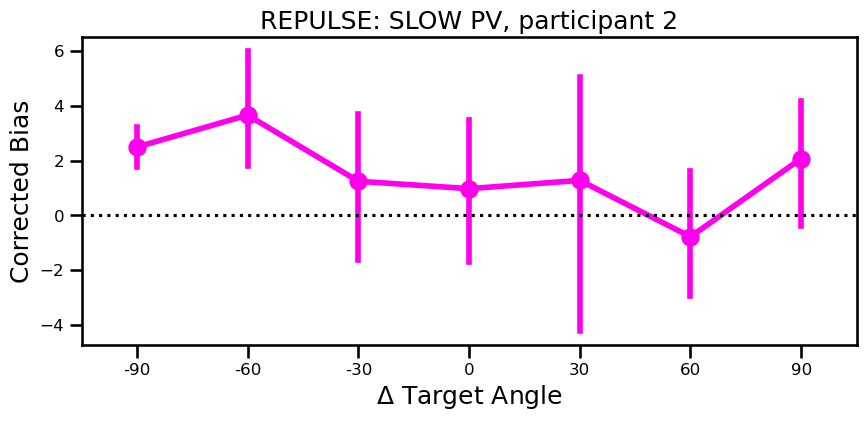

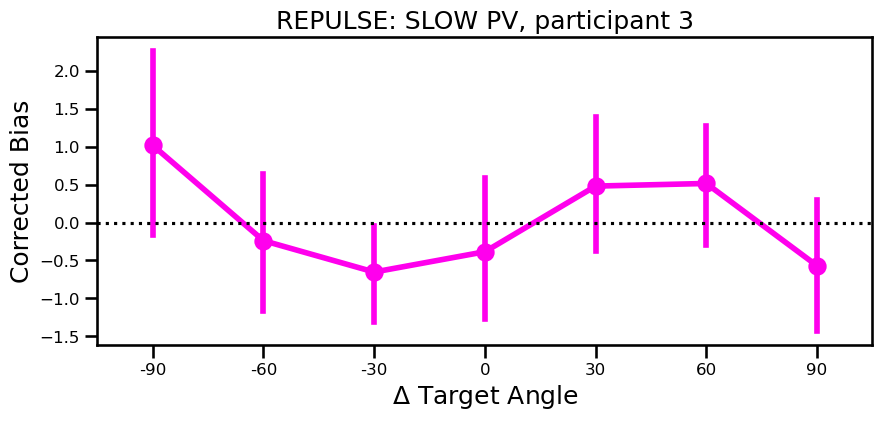

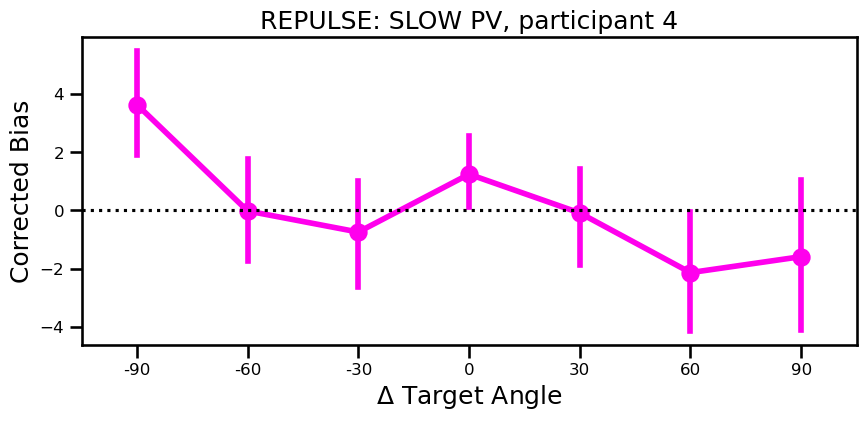

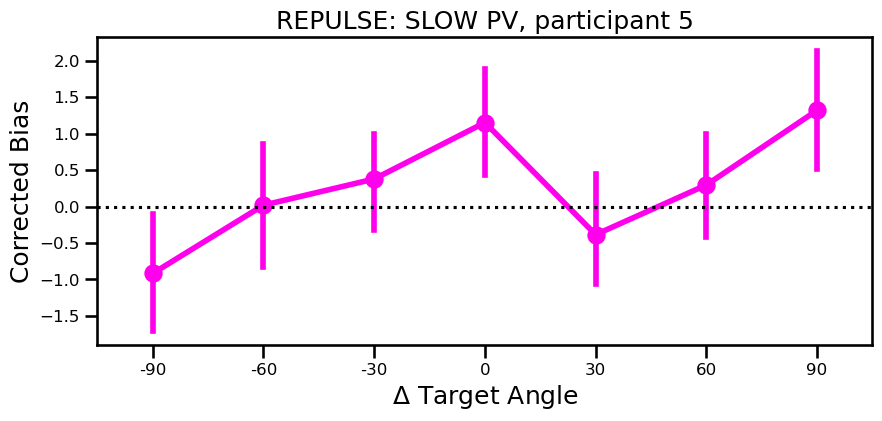

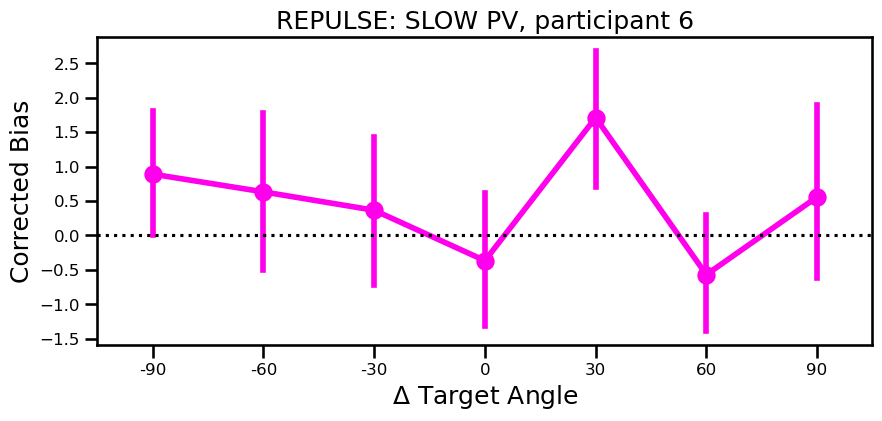

In [62]:
for sn in df_repulse_slow["SN"].unique():
    df_sn = df_repulse_slow[df_repulse_slow["SN"] == sn]

    fig, ax = plt.subplots(figsize=(10,4))
    sns.pointplot(
        data=df_sn,
        x='target_angle_diff',
        y='corrected_repulse_theta_pv',
        estimator='mean',
        errorbar=('ci',95),
        #color='black',
        ax=ax)

    
    ax.axhline(0, color='black', linestyle=':')
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    plt.title(f"REPULSE: SLOW PV, participant {sn}")
    plt.xlabel(r'$\Delta$ Target Angle')
    plt.ylabel('Corrected Bias')

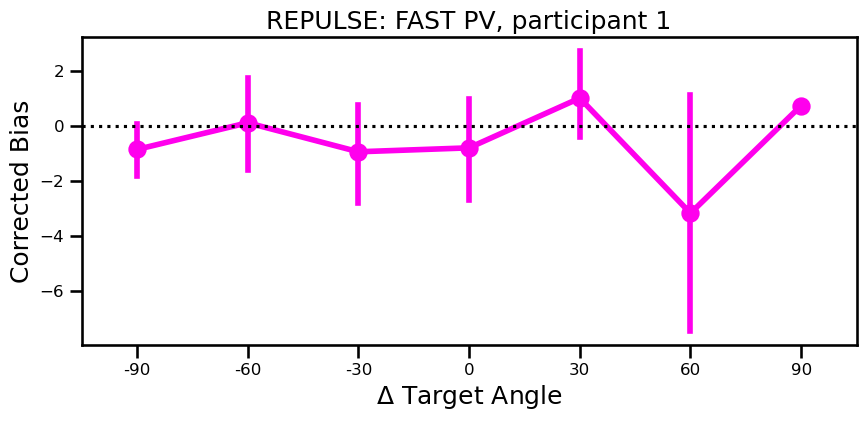

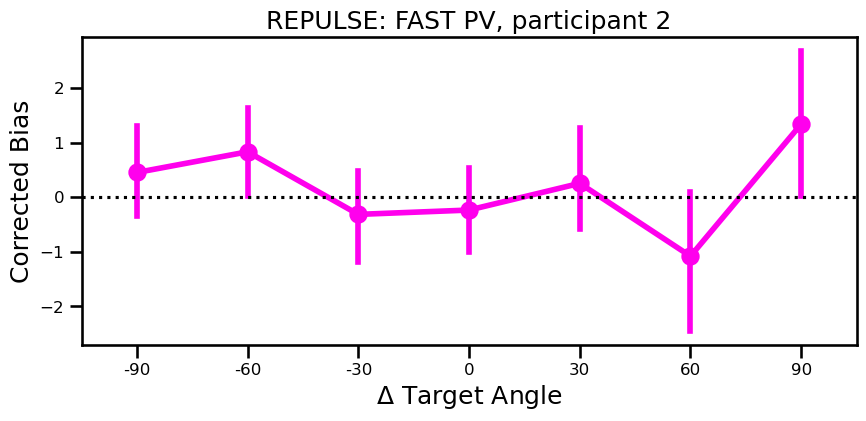

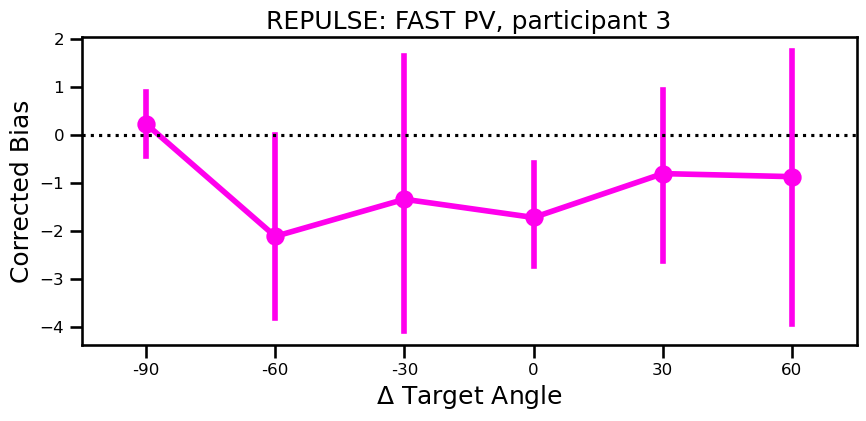

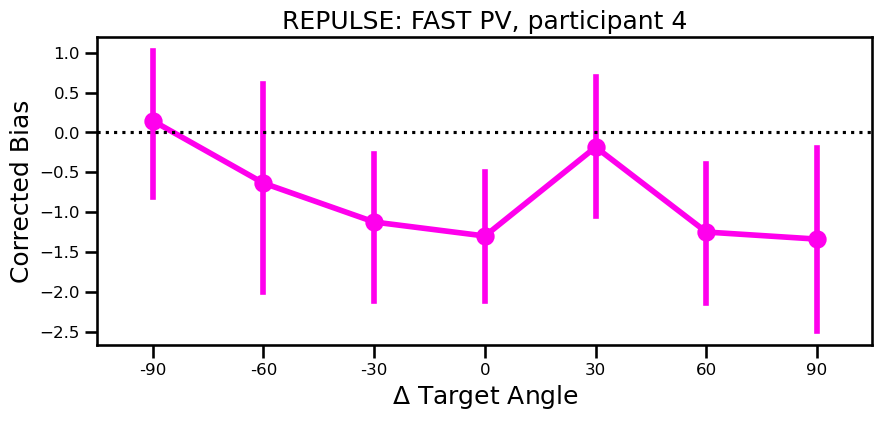

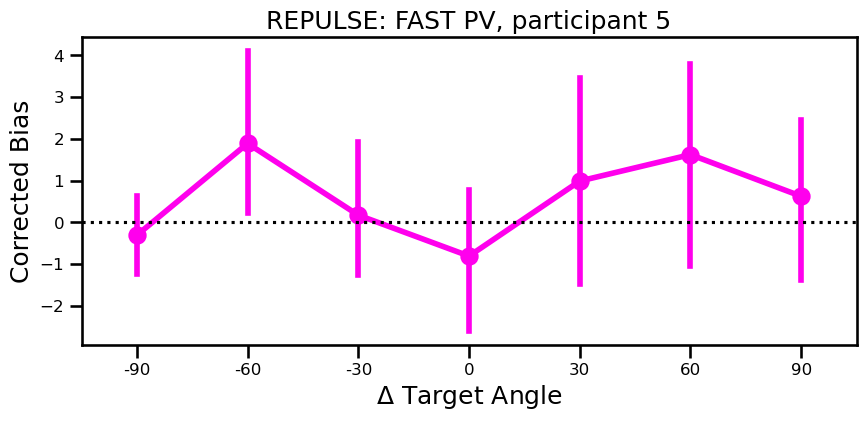

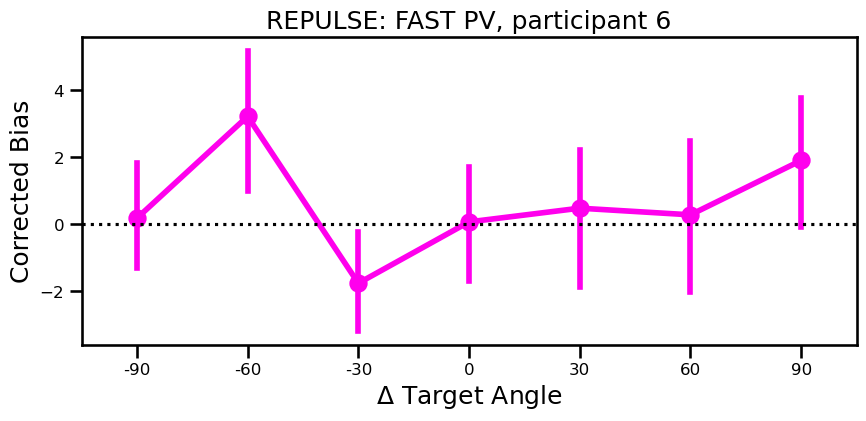

In [63]:
for sn in df_repulse_fast["SN"].unique():
    df_sn = df_repulse_fast[df_repulse_fast["SN"] == sn]

    fig, ax = plt.subplots(figsize=(10,4))
    sns.pointplot(
        data=df_sn,
        x='target_angle_diff',
        y='corrected_repulse_theta_pv',
        estimator='mean',
        errorbar=('ci',95),
        #color='black',
        ax=ax)

    
    ax.axhline(0, color='black', linestyle=':')
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    plt.title(f"REPULSE: FAST PV, participant {sn}")
    plt.xlabel(r'$\Delta$ Target Angle')
    plt.ylabel('Corrected Bias')

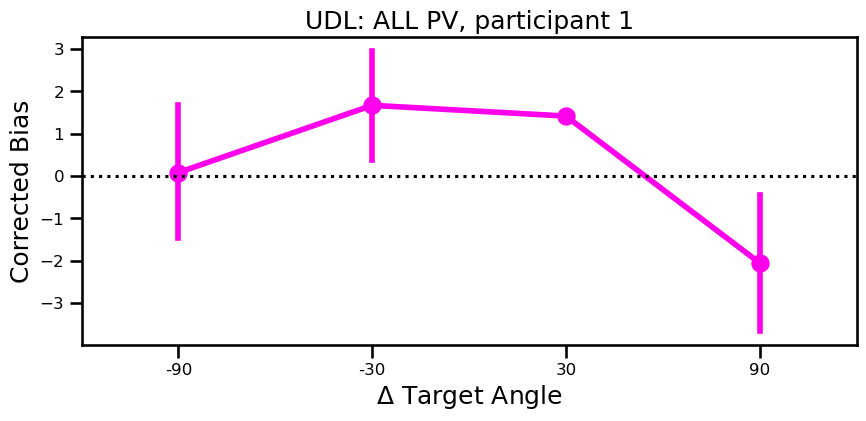

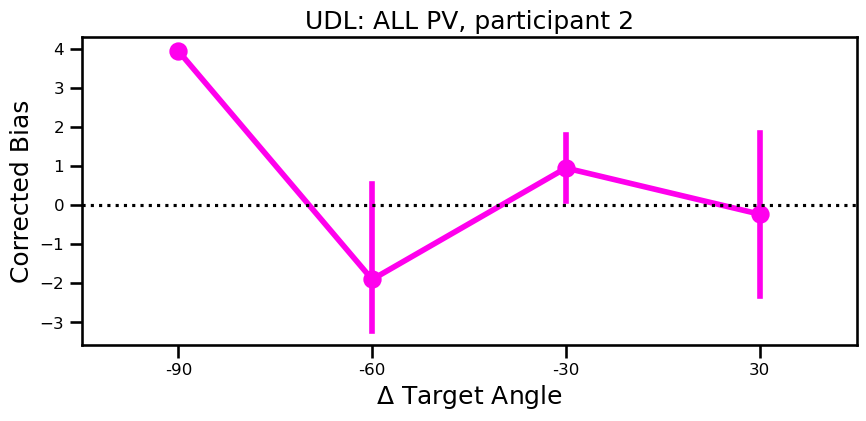

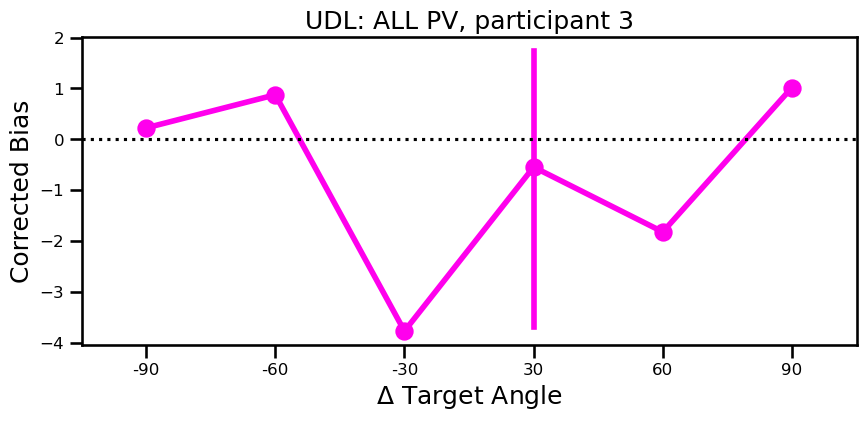

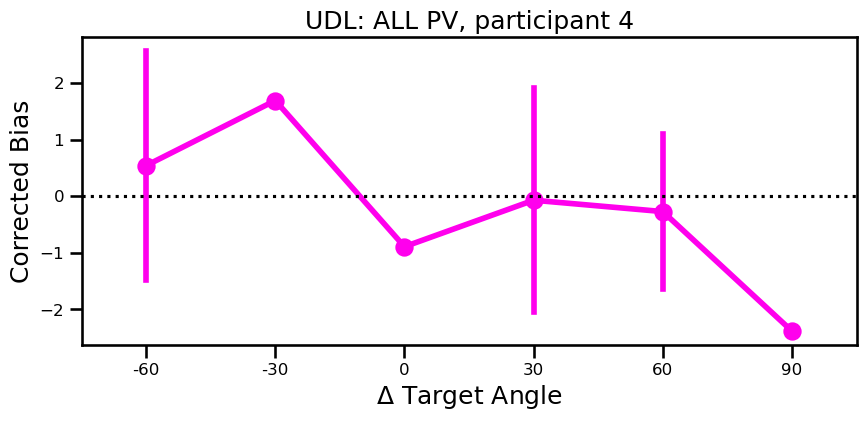

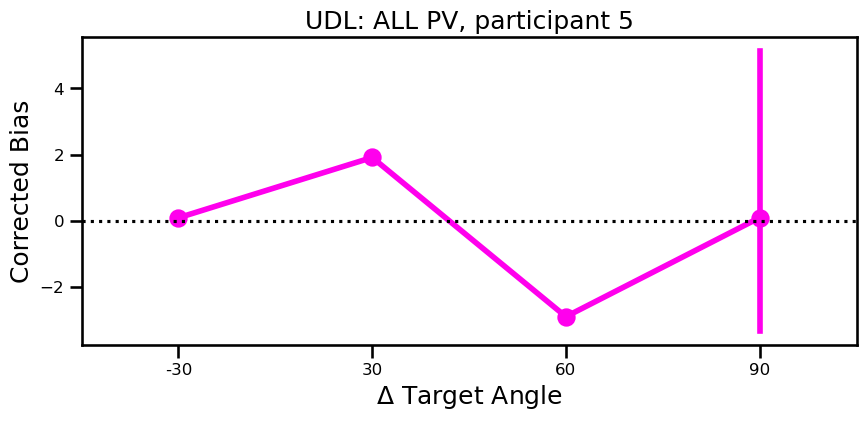

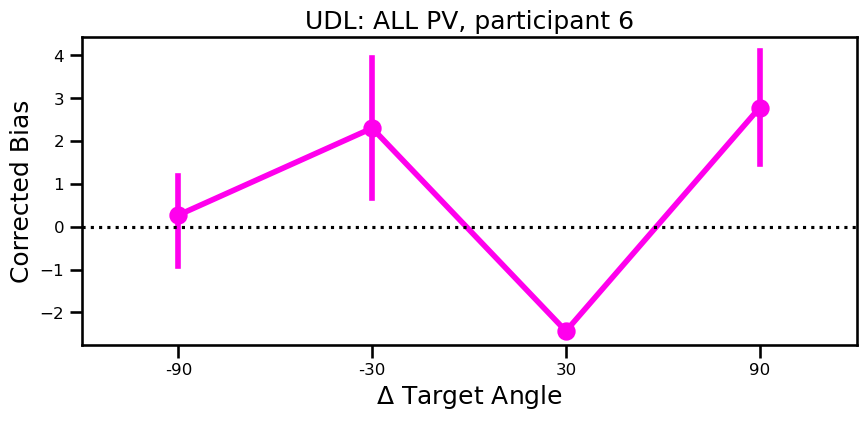

In [64]:
for sn in df_udl_constrained["SN"].unique():
    df_sn = df_udl_constrained[df_udl_constrained["SN"] == sn]

    fig, ax = plt.subplots(figsize=(10,4))
    sns.pointplot(
        data=df_sn,
        x='target_angle_diff',
        y='corrected_udl_theta_pv',
        estimator='mean',
        errorbar=('ci',95),
        #color='black',
        ax=ax)

    
    ax.axhline(0, color='black', linestyle=':')
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    plt.title(f"UDL: ALL PV, participant {sn}")
    plt.xlabel(r'$\Delta$ Target Angle')
    plt.ylabel('Corrected Bias')

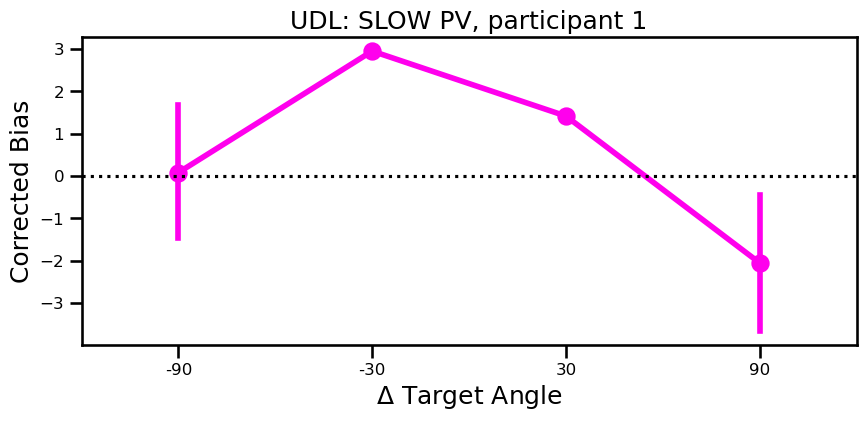

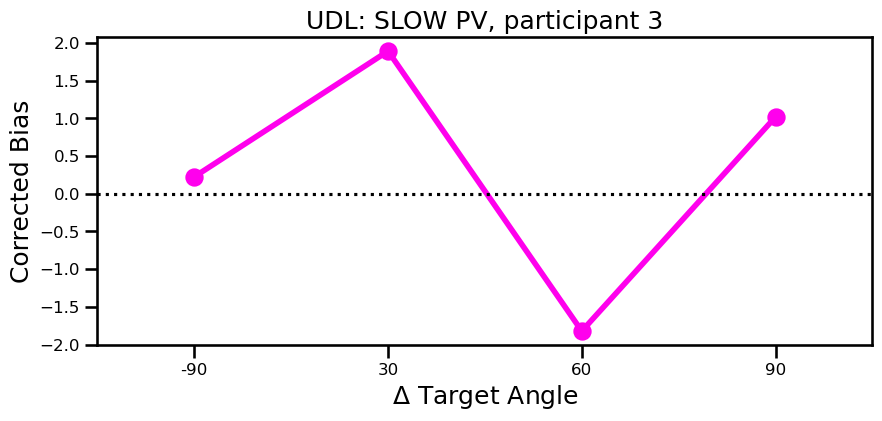

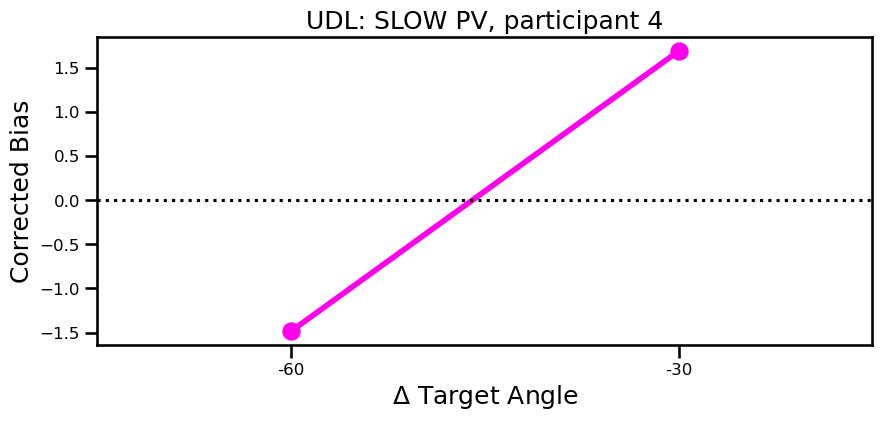

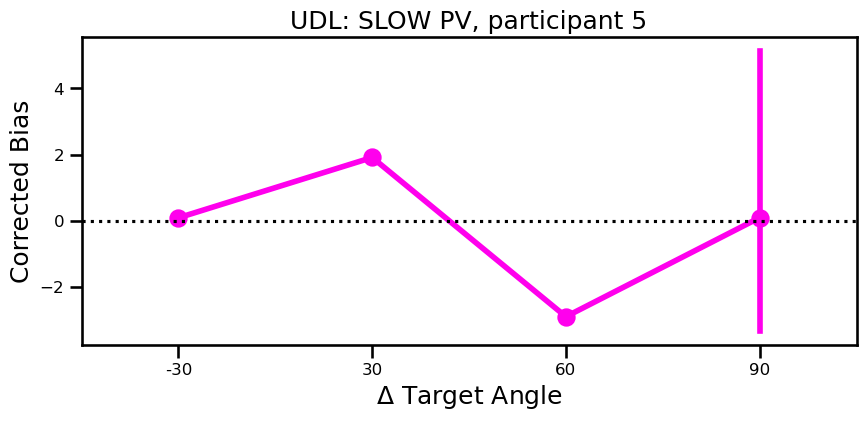

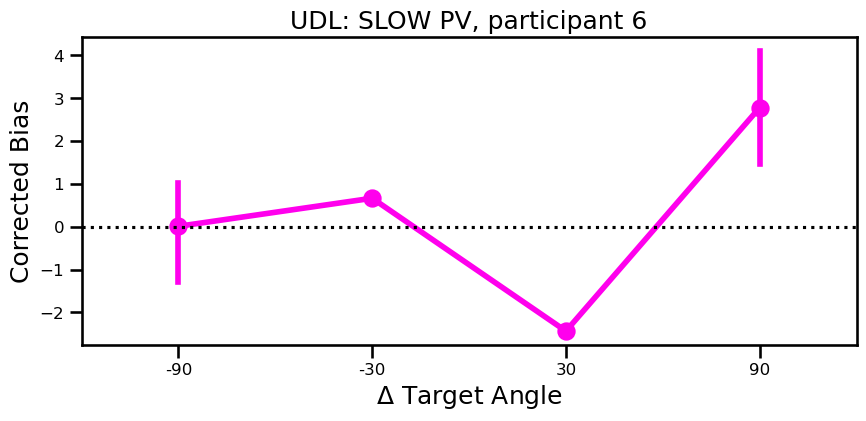

In [65]:
for sn in df_udl_constrained_slow["SN"].unique():
    df_sn = df_udl_constrained_slow[df_udl_constrained_slow["SN"] == sn]

    fig, ax = plt.subplots(figsize=(10,4))
    sns.pointplot(
        data=df_sn,
        x='target_angle_diff',
        y='corrected_udl_theta_pv',
        estimator='mean',
        errorbar=('ci',95),
        #color='black',
        ax=ax)

    
    ax.axhline(0, color='black', linestyle=':')
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    plt.title(f"UDL: SLOW PV, participant {sn}")
    plt.xlabel(r'$\Delta$ Target Angle')
    plt.ylabel('Corrected Bias')

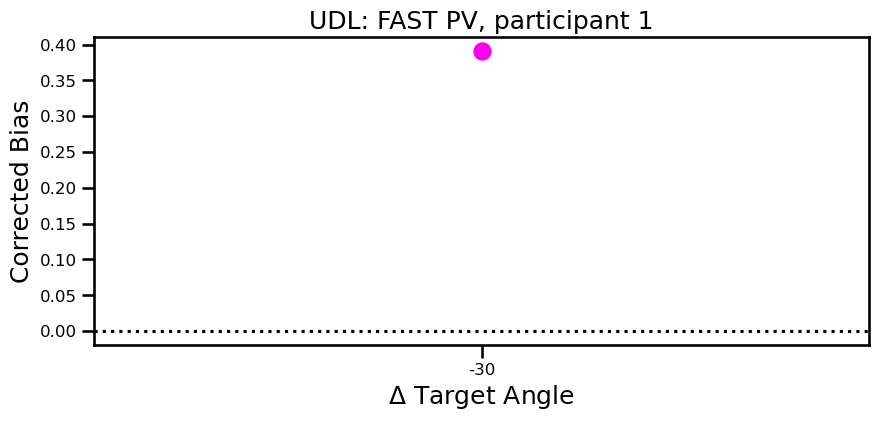

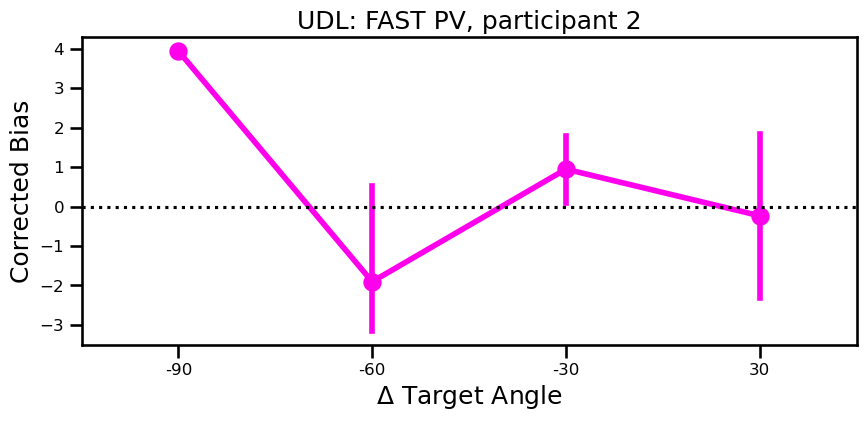

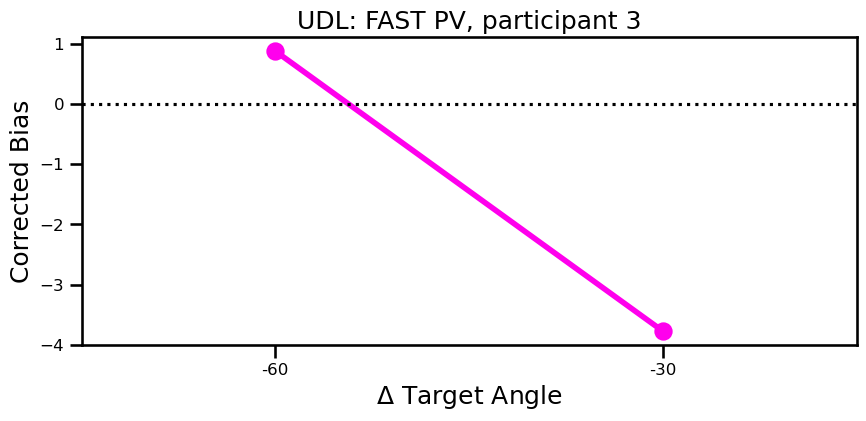

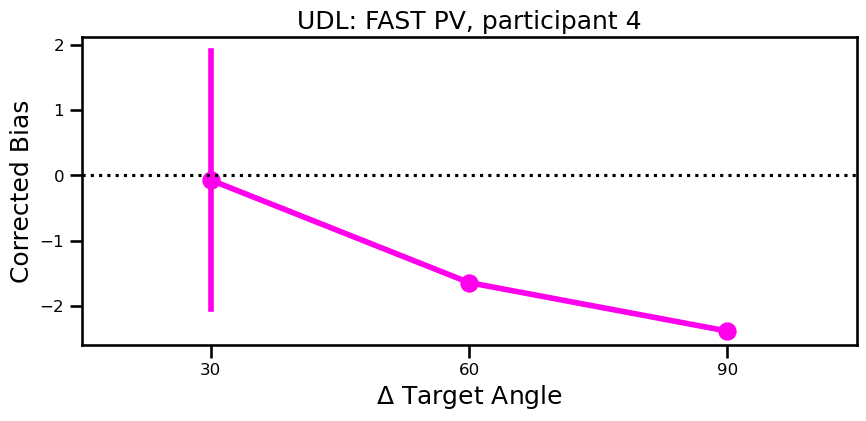

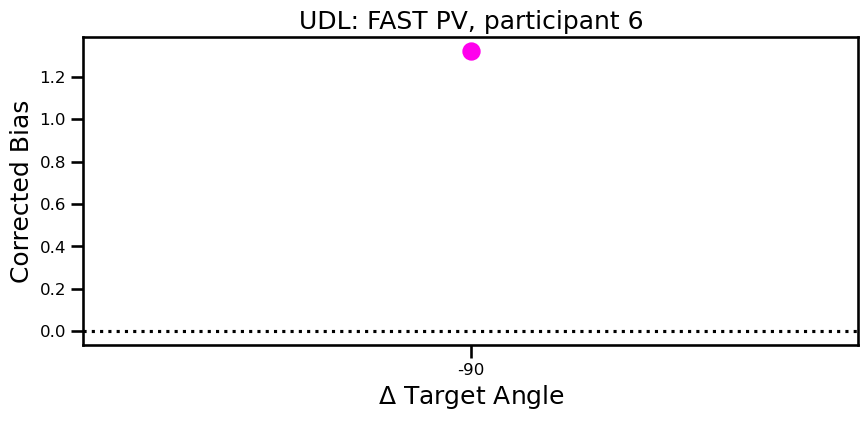

In [66]:
for sn in df_udl_constrained_fast["SN"].unique():
    df_sn = df_udl_constrained_fast[df_udl_constrained_fast["SN"] == sn]

    fig, ax = plt.subplots(figsize=(10,4))
    sns.pointplot(
        data=df_sn,
        x='target_angle_diff',
        y='corrected_udl_theta_pv',
        estimator='mean',
        errorbar=('ci',95),
        #color='black',
        ax=ax)

    
    ax.axhline(0, color='black', linestyle=':')
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    plt.title(f"UDL: FAST PV, participant {sn}")
    plt.xlabel(r'$\Delta$ Target Angle')
    plt.ylabel('Corrected Bias')

## Group level bias 

Text(0, 0.5, 'Corrected Bias')

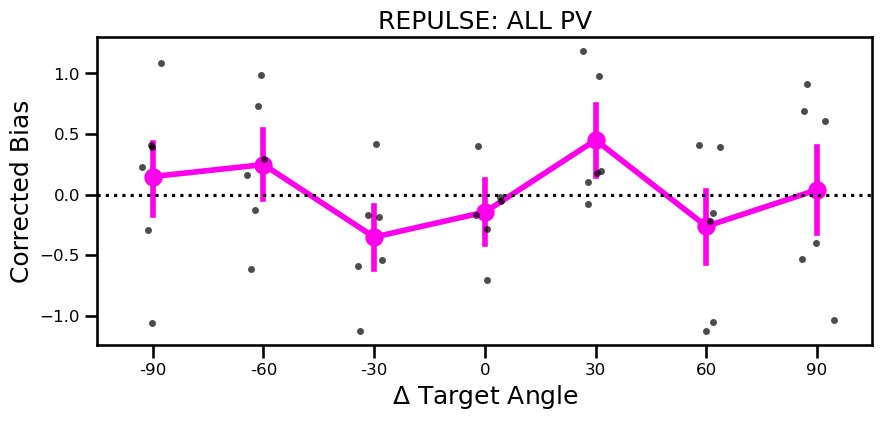

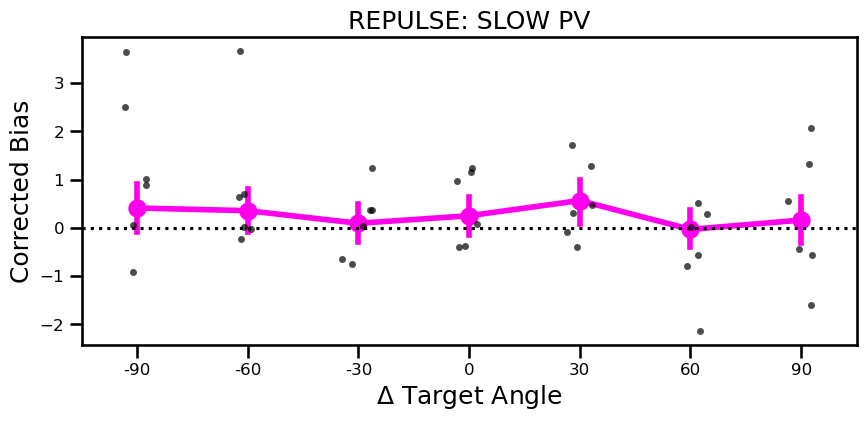

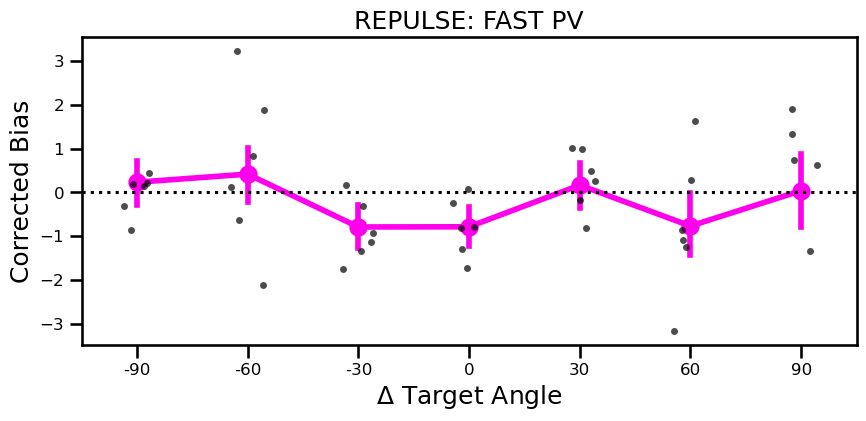

In [67]:
## ALL 
subject_means = (df_repulse.groupby(['SN', 'target_angle_diff'])['corrected_repulse_theta_pv' ].mean().reset_index())

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.title(f"REPULSE: ALL PV")
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

## SLOW 
subject_means = (df_repulse_slow.groupby(['SN', 'target_angle_diff'])['corrected_repulse_theta_pv' ].mean().reset_index())
fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse_slow,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.title(f"REPULSE: SLOW PV")
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

## FAST 
subject_means = (df_repulse_fast.groupby(['SN', 'target_angle_diff'])['corrected_repulse_theta_pv' ].mean().reset_index())

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse_fast,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.title(f"REPULSE: FAST PV")
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_39238/3176696094.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(N_finder, N_minus_targ=150)


Text(0, 0.5, 'Corrected Bias')

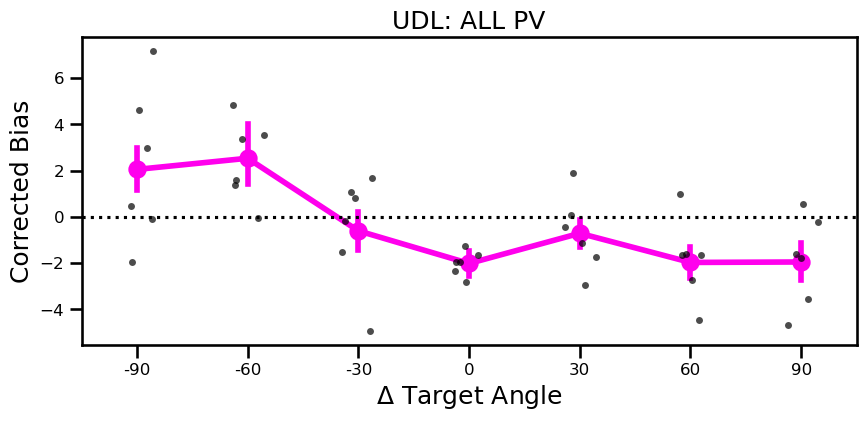

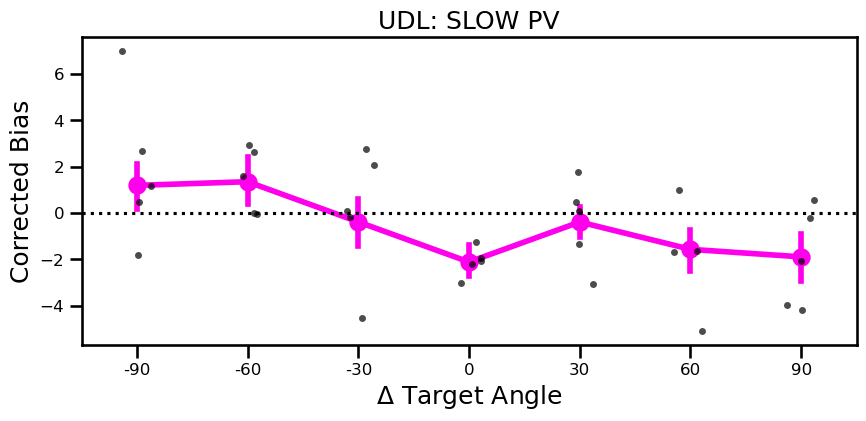

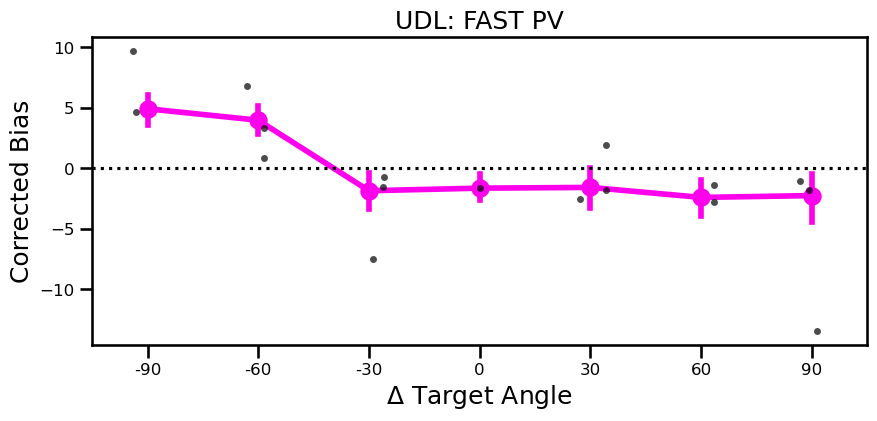

In [68]:
mask_udl = (
    (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1]) & 
    (~df['mt'].isna()) & 
    (df['rt'] > 0.500) & 
    (df['theta_pv'].abs() < 60)
)

df_udl = df.loc[mask_udl]
df_udl_constrained = (
    df_udl
    .groupby('SN', as_index=False)
    .apply(N_finder, N_minus_targ=150)
    .reset_index(drop=True)
)
df_udl_constrained = df_udl_constrained.loc[df_udl_constrained['feedback'] == 0]
## change to 'probe' == 1 

subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['corrected_udl_theta_pv'].mean().reset_index()

df_udl_constrained = df_udl_constrained.loc[df_udl_constrained['feedback'] == 0]
df_udl_constrained_slow = df_udl_constrained[df_udl_constrained["pv_category"] == "SLOW"]
df_udl_constrained_fast = df_udl_constrained[df_udl_constrained["pv_category"] == "FAST"]

## ALL 
subject_means = (df_udl_constrained.groupby(['SN', 'target_angle_diff'])['corrected_udl_theta_pv' ].mean().reset_index())

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.title(f"UDL: ALL PV")
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

## SLOW 
subject_means = (df_udl_constrained_slow.groupby(['SN', 'target_angle_diff'])['corrected_udl_theta_pv' ].mean().reset_index())

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained_slow,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.title(f"UDL: SLOW PV")
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

## FAST 
subject_means = (df_udl_constrained_fast.groupby(['SN', 'target_angle_diff'])['corrected_udl_theta_pv' ].mean().reset_index())

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained_fast,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.title(f"UDL: FAST PV")
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

## Movement Time 
#### (Wong & Haith, 2017)

slower mt = more pronounced bias --> used peak velocity, but can determine the average movement time 

**‘Fast’** (peak velocity, 0.8–1.5 m/s) --> average movement time 0.33 ± 0.02 s

**‘Slow’** (peak velocity, 0.3–0.7 m/s) --> average movement time 0.61 ± 0.10 s

** target was 20 cm away from home (ours is 10 cm, so divide the movement time by 2??)

**‘Fast’** average movement time 0.165 ± 0.10 s

**‘Slow’** average movement time 0.305 ± 0.10 s

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_39238/1235415133.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


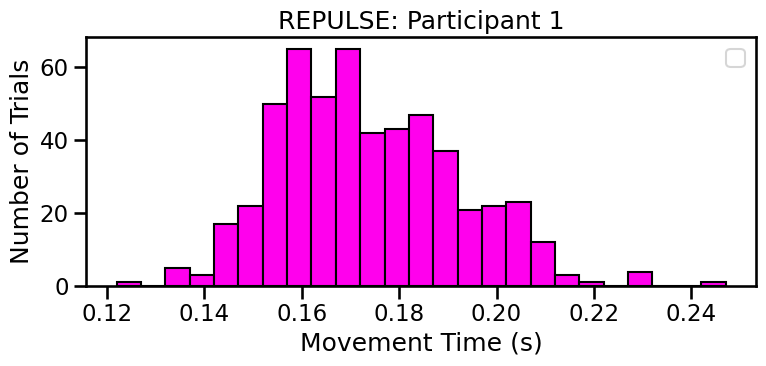

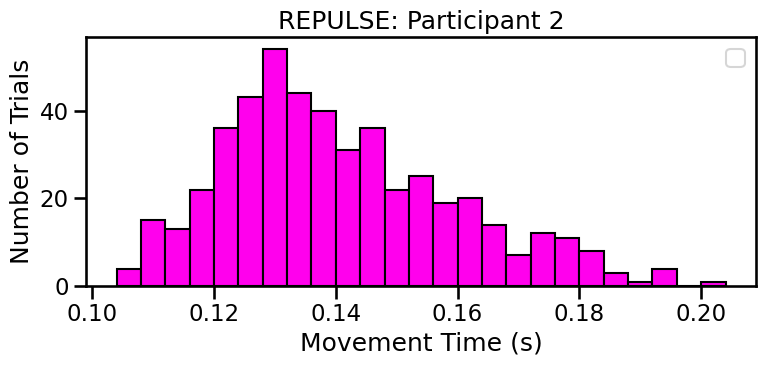

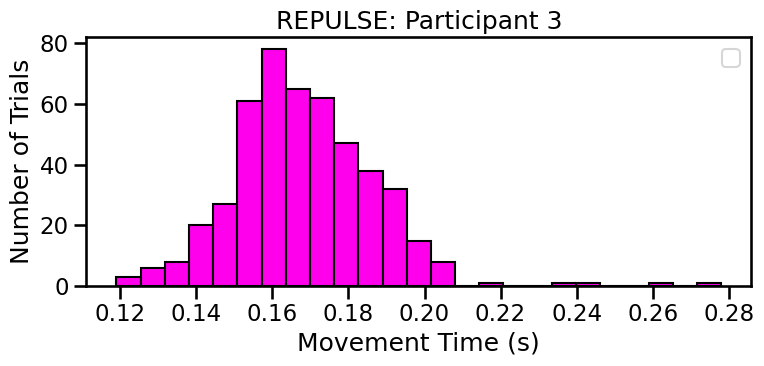

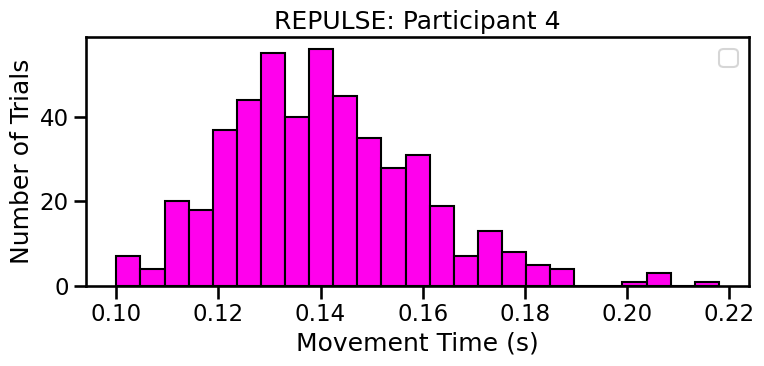

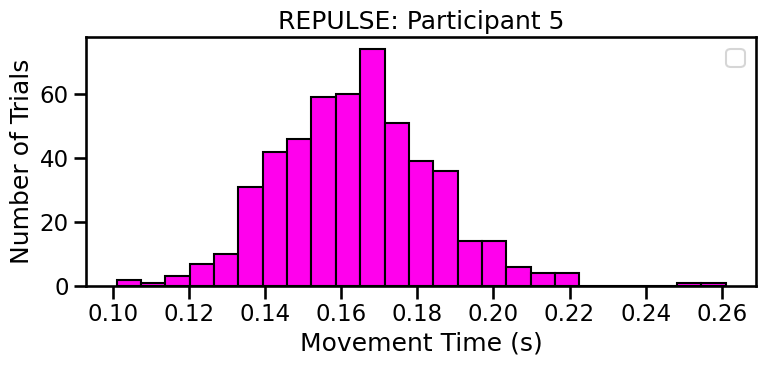

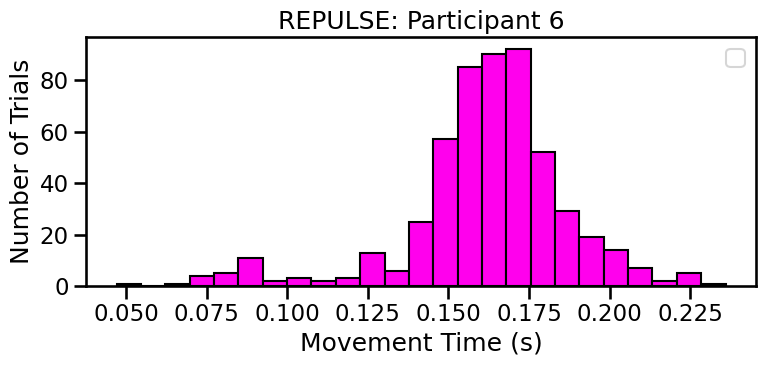

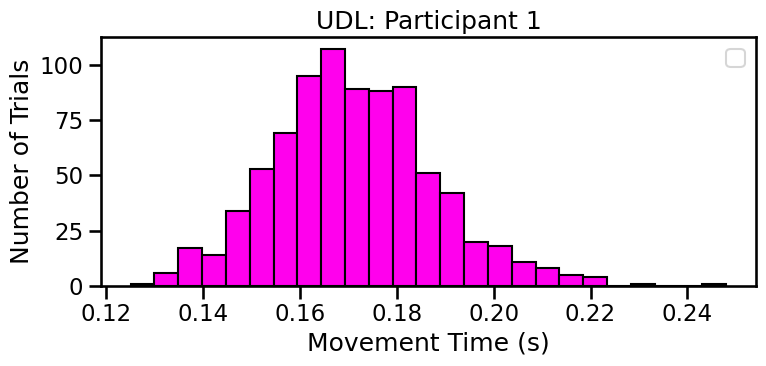

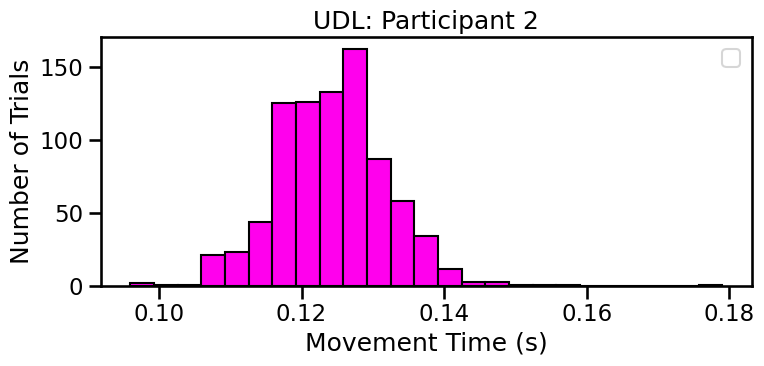

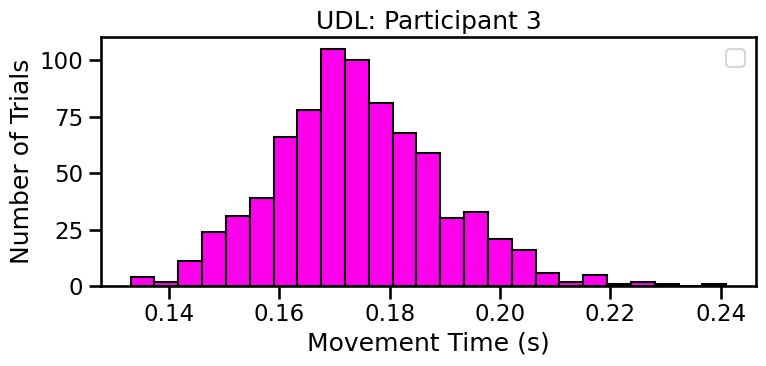

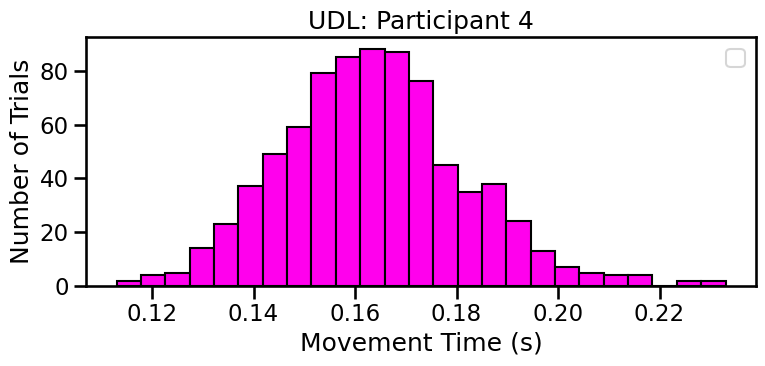

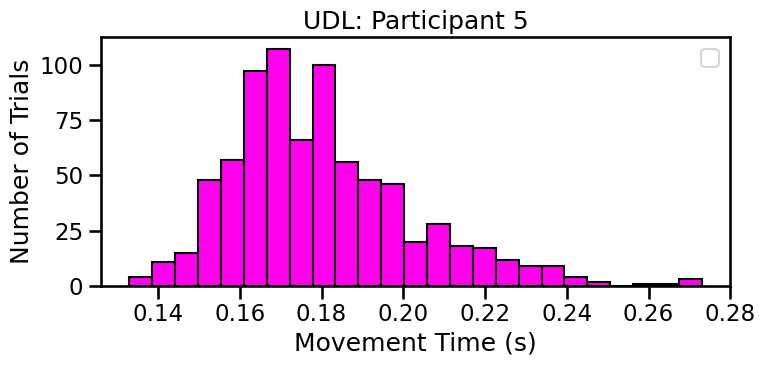

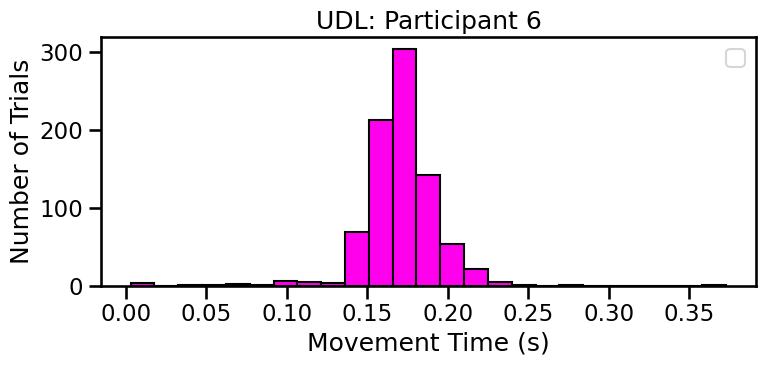

In [69]:
subjects = sorted(df["SN"].unique())

def plot_mt_histograms(df, phase_name, bins):
    """
    plotting function for movement time (MT) histograms for each participant; 
    regions for 'FAST' and 'SLOW' are indicated in red and blue respectively
    """
    for sn in subjects:

        mt = df.loc[df["SN"] == sn, "mt"].dropna()

        fig, ax = plt.subplots(figsize=(8, 4))

        # plot histogram
        ax.hist(
            mt,
            bins=bins,
            edgecolor="black")

        # # SLOW shaded region
        # ax.axvspan(
        #     0.305 - 0.10,
        #     0.305 + 0.10,
        #     alpha=0.25,
        #     color="steelblue",
        #     label="SLOW (0.305 ± 0.10 s)")

        # # FAST shaded region
        # ax.axvspan(
        #     0.165 - 0.10,
        #     0.165 + 0.10,
        #     alpha=0.25,
        #     color="tomato",
        #     label="FAST (0.165 ± 0.10 s)")

        ax.set_title(f"{phase_name}: Participant {sn}")
        ax.set_xlabel("Movement Time (s)")
        ax.set_ylabel("Number of Trials")

        ax.legend()
        plt.tight_layout()
        plt.show()


plot_mt_histograms(df_repulse, "REPULSE", 25)
plot_mt_histograms(df_udl, "UDL", 25)

# SE index vs Peak Velocity 

+ SE (Sequential Effect) index is a compact summary statistic that quantifies how strongly the previous trial's target biases the current movement
+ mean bias for ΔTarget Angle < 0 deg 
+ mean bias for ΔTarget Angle > 0 deg 
+ SE index = negative mean - positive mean
  + POSITIVE SE Index = attractive bias (UDL)
  + NEGATIVE SE Index = repulsive bias (REPULSE)

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_39238/859268998.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(N_finder, N_minus_targ=150)


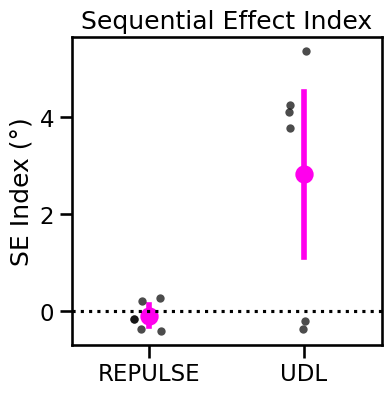

SN
1   -0.159241
2    0.275488
3   -0.406009
4    0.214646
5   -0.367853
6   -0.161490
Name: corrected_repulse_theta_pv, dtype: float64


In [70]:
mask_udl = (
    (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1]) & 
    (~df['mt'].isna()) & 
    (df['rt'] > 0.500) & 
    (df['theta_pv'].abs() < 60)
)

df_udl = df.loc[mask_udl].copy()

df_udl_constrained = (
    df_udl
    .groupby('SN', as_index=False)
    .apply(N_finder, N_minus_targ=150)
    .reset_index(drop=True)
).copy()

df_udl_constrained = df_udl_constrained.loc[df_udl_constrained['feedback'] == 0]
## change to 'probe' == 1 

se_repulse = calculate_se_index(df_repulse, "corrected_repulse_theta_pv")
se_udl = calculate_se_index(df_udl_constrained,"corrected_udl_theta_pv")

se_df = pd.DataFrame({
    "REPULSE": se_repulse,
    "UDL": se_udl
}).reset_index()

se_df = se_df.melt(
    id_vars="SN",
    var_name="Condition",
    value_name="SE_index"
)

fig, ax = plt.subplots(figsize=(4,4))

sns.stripplot(
    data=se_df,
    x="Condition",
    y="SE_index",
    color="black",
    alpha=0.7,
    jitter=True,
    size=6,
    ax=ax
)

sns.pointplot(
    data=se_df,
    x="Condition",
    y="SE_index",
    estimator="mean",
    errorbar=("ci",95),
    # color="black",
    linestyles="",
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")

ax.set_ylabel("SE Index (°)")
ax.set_xlabel("")
ax.set_title("Sequential Effect Index")

plt.show()
print(se_repulse)

# SOMETHING IS WRONG HERE??? MAYBE DO THE MANUAL CALCULATIONS FOR THE SE INDEX? 


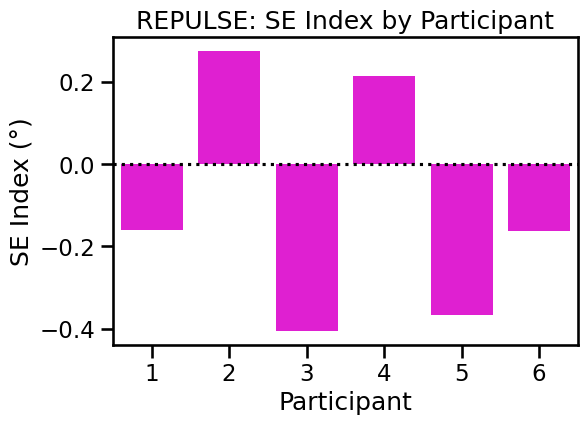

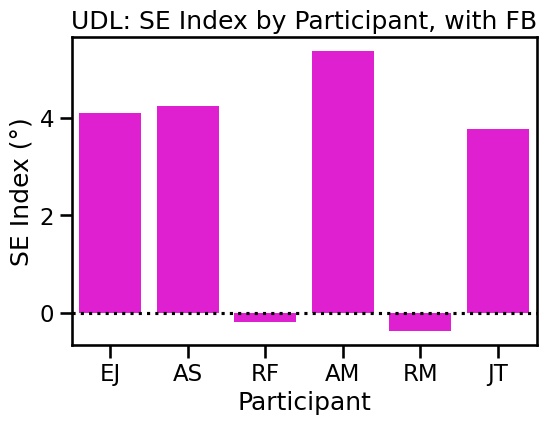

In [72]:
repulse_all = se_df[se_df["Condition"] == "REPULSE"]
udl_all = se_df[se_df["Condition"] == "UDL"]

# REPULSE 
fig, ax = plt.subplots(figsize=(6,4))

sns.barplot(
    data=repulse_all,
    x="SN",
    y="SE_index",
    errorbar=None,
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")
ax.set_xlabel("Participant")
ax.set_ylabel("SE Index (°)")
ax.set_title("REPULSE: SE Index by Participant")

plt.show()

subjects = ["EJ", "AS", "RF", "AM", "RM", "JT"] 
# UDL 
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(
    data=udl_all,
    x=subjects,
    # x = 'SN',
    y="SE_index",
    errorbar=None,
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")
ax.set_xlabel("Participant")
ax.set_ylabel("SE Index (°)")
ax.set_title("UDL: SE Index by Participant, with FB")

plt.show()

In [73]:
udl_manual = df_udl_constrained.copy()

manual_se = (
    udl_manual
    .groupby("SN")
    .apply(
        lambda x: pd.Series({
            "negative_mean": x.loc[
                x["target_angle_diff"] < 0,
                "corrected_udl_theta_pv"
            ].mean(),

            "positive_mean": x.loc[
                x["target_angle_diff"] > 0,
                "corrected_udl_theta_pv"
            ].mean()
        })
    )
)

manual_se["SE_index"] = (
    manual_se["negative_mean"]
    - manual_se["positive_mean"]
)

manual_se

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_39238/2831487086.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,negative_mean,positive_mean,SE_index
SN,,,
1,2.080218,-2.028460,4.108679
2,2.150915,-2.103029,4.253944
3,-0.549093,-0.350865,-0.198228
4,4.149287,-1.227306,5.376593
5,0.520539,0.897641,-0.377102
6,-0.313669,-4.089001,3.775331


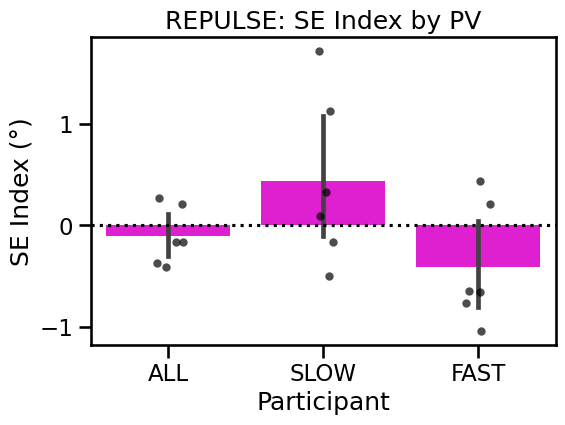

In [74]:
se_repulse = calculate_se_index(df_repulse, "corrected_repulse_theta_pv")
se_repulse_slow = calculate_se_index(df_repulse_slow, "corrected_repulse_theta_pv")
se_repulse_fast = calculate_se_index(df_repulse_fast, "corrected_repulse_theta_pv")

se_repulse_df = pd.DataFrame({
    "ALL": se_repulse,
    "SLOW": se_repulse_slow, 
    "FAST": se_repulse_fast, 
}).reset_index()

se_repulse_df = se_repulse_df.melt(
    id_vars="SN",
    var_name="Category",
    value_name="SE_index"
)

# PLOT 
fig, ax = plt.subplots(figsize=(6,4))

sns.barplot(
    data=se_repulse_df,
    x="Category",
    y="SE_index",
    errorbar=('ci',95),
    ax=ax
)

sns.stripplot(
    data=se_repulse_df,
    x="Category",
    y="SE_index",
    color="black",
    alpha=0.7,
    jitter=True,
    size=6,
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")
ax.set_xlabel("Participant")
ax.set_ylabel("SE Index (°)")
ax.set_title("REPULSE: SE Index by PV")

plt.show()


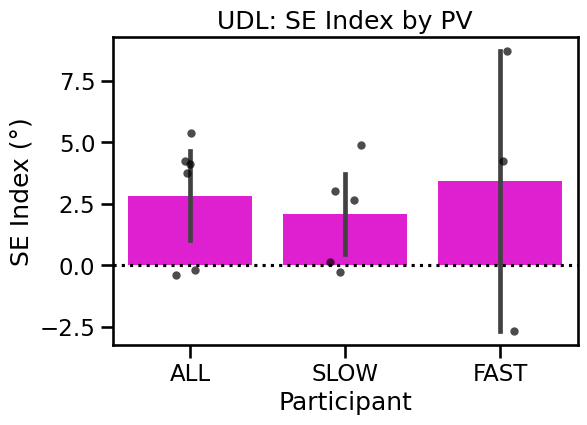

In [75]:
se_udl = calculate_se_index(df_udl_constrained, "corrected_udl_theta_pv")
se_udl_slow = calculate_se_index(df_udl_constrained_slow, "corrected_udl_theta_pv")
se_udl_fast = calculate_se_index(df_udl_constrained_fast, "corrected_udl_theta_pv")

se_udl_df = pd.DataFrame({
    "ALL": se_udl,
    "SLOW": se_udl_slow, 
    "FAST": se_udl_fast, 
}).reset_index()

se_udl_df = se_udl_df.melt(
    id_vars="SN",
    var_name="Category",
    value_name="SE_index"
)

# PLOT 
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(
    data=se_udl_df,
    x="Category",
    y="SE_index",
    errorbar=('ci',95),
    ax=ax
)

sns.stripplot(
    data=se_udl_df,
    x="Category",
    y="SE_index",
    color="black",
    alpha=0.7,
    jitter=True,
    size=6,
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")
ax.set_xlabel("Participant")
ax.set_ylabel("SE Index (°)")
ax.set_title("UDL: SE Index by PV")

plt.show()

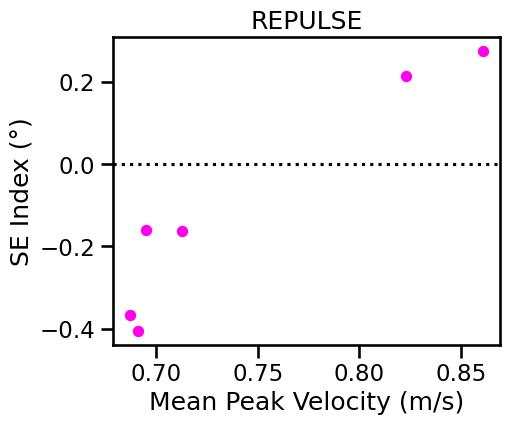

In [76]:
se_repulse = calculate_se_index(df_repulse, "corrected_repulse_theta_pv")
mean_pv_repulse = df_repulse.groupby("SN")["peak_vel"].mean()

repulse_scatter = pd.concat(
    [se_repulse.rename("SE_index"),
     mean_pv_repulse.rename("mean_PV")],
    axis=1
).reset_index()

# plot
fig, ax = plt.subplots(figsize=(5,4))
sns.scatterplot(
    data=repulse_scatter,
    x="mean_PV",
    y="SE_index",
    s=80,
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")
ax.set_xlabel("Mean Peak Velocity (m/s)")
ax.set_ylabel("SE Index (°)")
ax.set_title("REPULSE")
plt.show()

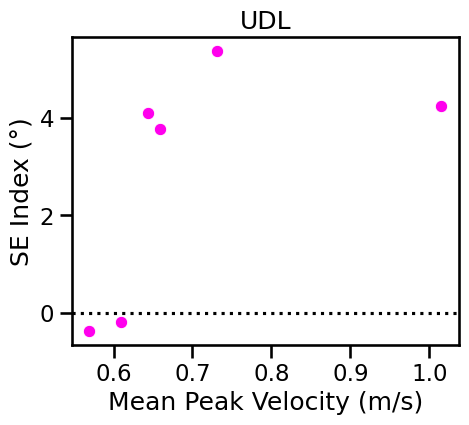

In [77]:
se_udl = calculate_se_index(df_udl_constrained, "corrected_udl_theta_pv")
mean_pv_udl = df_udl_constrained.groupby("SN")["peak_vel"].mean()

repulse_scatter = pd.concat(
    [se_udl.rename("SE_index"),
     mean_pv_udl.rename("mean_PV")],
    axis=1
).reset_index()

# plot
fig, ax = plt.subplots(figsize=(5,4))
sns.scatterplot(
    data=repulse_scatter,
    x="mean_PV",
    y="SE_index",
    s=80,
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")
ax.set_xlabel("Mean Peak Velocity (m/s)")
ax.set_ylabel("SE Index (°)")
ax.set_title("UDL")
plt.show()

## Motor Variability 

looking at the variance of theta_PV for 150 deg target reaches in the REPULSE phase (100 trials) and UDL phase (last 100 trials)

also look at UDL baseline no feedback?? 

In [78]:
repulse_var = (
    df_repulse[df_repulse["target_angle"] == 150]
    .groupby("SN")["theta_pv"]
    .var()
    .rename("variance")
)

df_baseline = df.loc[
            (df['TN'] >= epochs['udl_baseline_noFB'][0]) & (df['TN'] <= epochs['udl_baseline_noFB'][1]) &
            (~df["mt"].isna()) &
            (df["rt"] > 0.5) &
            (df['theta_pv'].abs() < 60)
        ]

baseline_var = (
    df_baseline[df_baseline["target_angle"] == 150]
    .groupby("SN")["theta_pv"]
    .var()
    .rename("variance")
)


udl_last100 = (
    df_udl_constrained[df_udl_constrained["target_angle"] == 150].sort_values(["SN", "TN"])
    .groupby("SN", group_keys=False)
    .tail(100)
)

udl_var = (
    udl_last100
    .groupby("SN")["theta_pv"]
    .var()
    .rename("variance")
)

motor_var = pd.concat(
    [
        repulse_var.rename("REPULSE"),
        baseline_var.rename("BASELINE"),
        udl_var.rename("UDL")
    ],
    axis=1
).reset_index()

motor_var = motor_var.melt(
    id_vars="SN",
    var_name="Phase",
    value_name="variance"
)

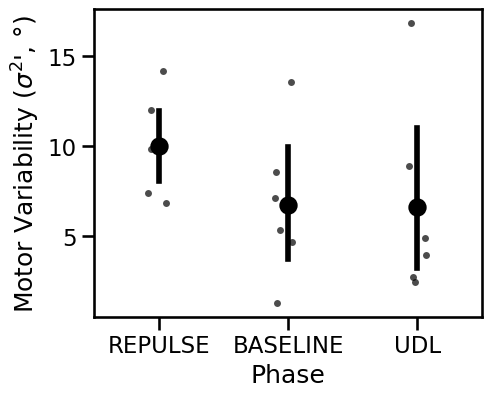

In [79]:
fig, ax = plt.subplots(figsize=(5,4))

sns.stripplot(
    data=motor_var,
    x="Phase",
    y="variance",
    color="black",
    jitter=True,
    alpha=0.7,
    ax=ax
)

sns.pointplot(
    data=motor_var,
    x="Phase",
    y="variance",
    estimator="mean",
    errorbar=("ci", 95),
    color="black",
    linestyles="",
    ax=ax
)

ax.set_ylabel("Motor Variability ($\sigma^2$', °)")
plt.show()

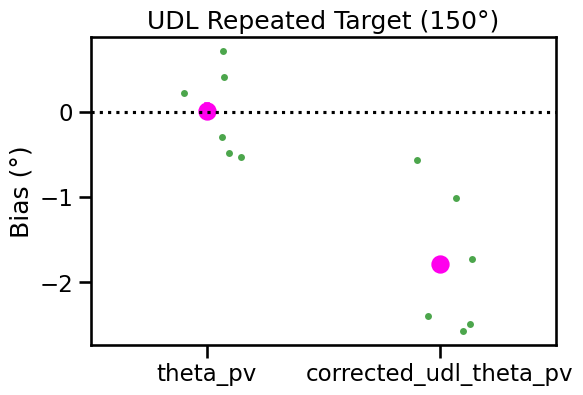

In [80]:
# only repeated target (150°)
udl_150 = df_udl[df_udl["target_angle"] == 150].copy()
subject_means = udl_150.groupby("SN")[["theta_pv", "corrected_udl_theta_pv"]].mean().reset_index()


# convert to long format for plotting
plot_df = udl_150.melt(
    id_vars=["SN"],
    value_vars=["theta_pv", "corrected_udl_theta_pv"],
    var_name="bias_type",
    value_name="value"
)

subject_means = subject_means.melt(
    id_vars="SN",
    value_vars=["theta_pv", "corrected_udl_theta_pv"],
    var_name="bias_type",
    value_name="value"
)



fig, ax = plt.subplots(figsize=(6,4))

sns.pointplot(
    data=plot_df,
    x="bias_type",
    y="value",
    estimator="mean",
    errorbar=("ci",95),
    linestyles="",
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x="bias_type",
    y="value",
    color="green",
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")

ax.set_ylabel("Bias (°)")
ax.set_xlabel("")
ax.set_title("UDL Repeated Target (150°)")

plt.show()

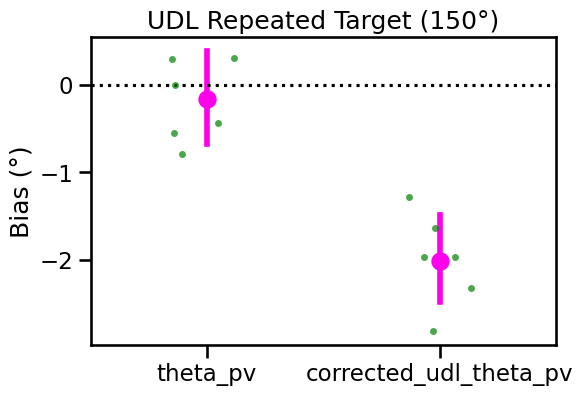

In [81]:
# only repeated target (150°)
udl_150 = df_udl_constrained[df_udl_constrained["target_angle"] == 150].copy()
subject_means = udl_150.groupby("SN")[["theta_pv", "corrected_udl_theta_pv"]].mean().reset_index()


# convert to long format for plotting
plot_df = udl_150.melt(
    id_vars=["SN"],
    value_vars=["theta_pv", "corrected_udl_theta_pv"],
    var_name="bias_type",
    value_name="value"
)

subject_means = subject_means.melt(
    id_vars="SN",
    value_vars=["theta_pv", "corrected_udl_theta_pv"],
    var_name="bias_type",
    value_name="value"
)



fig, ax = plt.subplots(figsize=(6,4))

sns.pointplot(
    data=plot_df,
    x="bias_type",
    y="value",
    estimator="mean",
    errorbar=("ci",95),
    linestyles="",
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x="bias_type",
    y="value",
    color="green",
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")

ax.set_ylabel("Bias (°)")
ax.set_xlabel("")
ax.set_title("UDL Repeated Target (150°)")

plt.show()

## COMPARE 60 deg vs 150 deg central target 

In [82]:
central_60 = [1, 3, 5]
central_150 = [2, 4]

udl_60 = df_udl_constrained[df_udl_constrained["SN"].isin(central_60)].copy()
udl_150 = df_udl_constrained[df_udl_constrained["SN"].isin(central_150)].copy()

Text(0, 0.5, 'Corrected Bias')

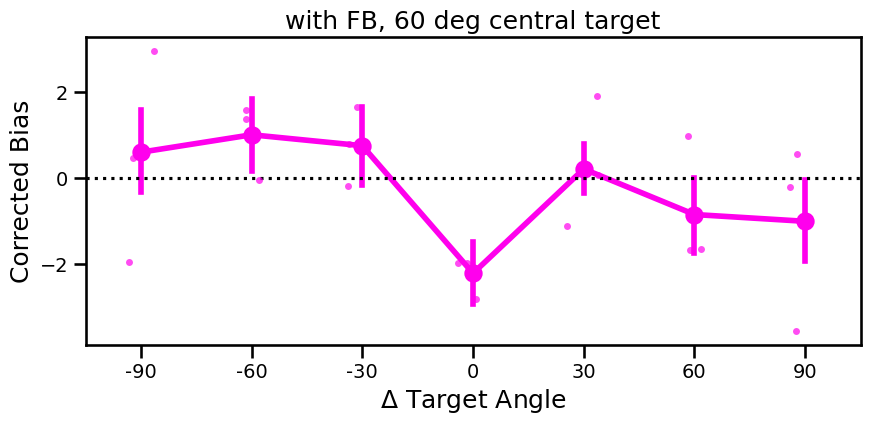

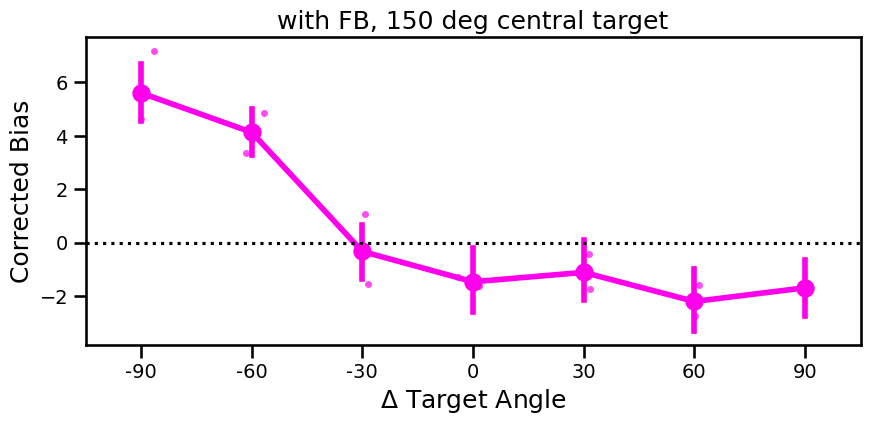

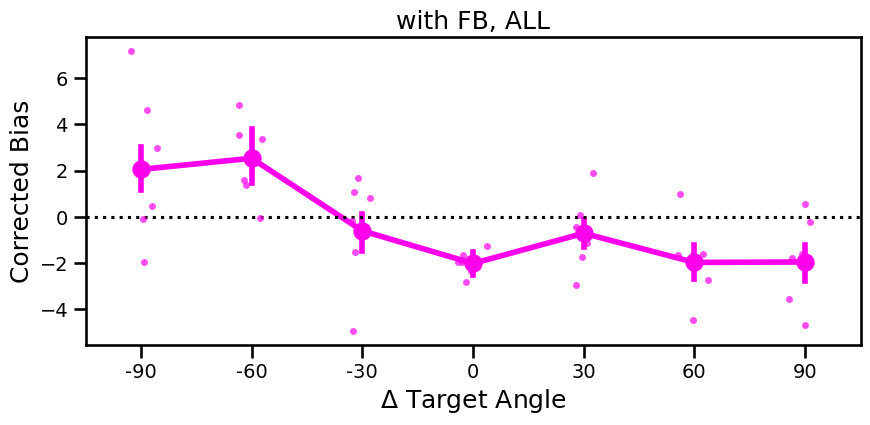

In [83]:
subject_means = udl_60.groupby(['SN', 'target_angle_diff'])['corrected_udl_theta_pv'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=udl_60,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    #color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.title('with FB, 60 deg central target')
plt.ylabel('Corrected Bias') 

subject_means = udl_150.groupby(['SN', 'target_angle_diff'])['corrected_udl_theta_pv'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=udl_150,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    #color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.title('with FB, 150 deg central target')
plt.ylabel('Corrected Bias') 

subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['corrected_udl_theta_pv'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_udl_theta_pv',
    #color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.title('with FB, ALL')
plt.ylabel('Corrected Bias') 
